In [ ]:
#activate venv: 

import pandas as pd
import time
#other requirements: sklearn, matplotlib, statsmodels

In [2]:
start=time.perf_counter()

In [3]:
from DatabaseCreator import DatabaseCreator
import CJDH_local_settings

#Run Database Creator
if __name__ == "__main__":
    db_creator = DatabaseCreator(db_settings=CJDH_local_settings.local_settings['FPL_Points_Predictor'])
    fpl_engine = db_creator.get_engine_for("fpl_data_analysis")

In [4]:
from FPLPredictor import FPLPredictor

In [5]:
#add this info to a settings dict?
stats_current_gameweek = 16
picks_current_gameweek = 16
current_season = 20252026

In [6]:
# Load df from sql
df = db_creator.run_sql("""SELECT *
                        FROM playergw_transformed
                          """)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147334 entries, 0 to 147333
Columns: 430 entries, player_name_id to saves_elo_p90sq_10
dtypes: float64(425), object(5)
memory usage: 483.3+ MB


In [7]:
df.columns.tolist()

['player_name_id',
 'element',
 'season',
 'value',
 'event',
 'minutes',
 'total_points',
 'team_elo',
 'opp_team_elo',
 'position',
 'goals_scored',
 'bonus',
 'bps',
 'clean_sheets',
 'goals_conceded',
 'was_home',
 'expected_goals',
 'expected_assists',
 'expected_goal_involvements',
 'expected_goals_conceded',
 'team_name',
 'opp_team_name',
 'cbi',
 'defensive_contribution',
 'recoveries',
 'tackles',
 'saves',
 'player_season_minutes_total',
 'player_season_points_per90',
 'points_per90',
 'expected_goals_per90',
 'expected_assists_per90',
 'expected_goals_conceded_per90',
 'saves_per90',
 'bps_per90',
 'bonus_per90',
 'cbi_per90',
 'defensive_contribution_per90',
 'recoveries_per90',
 'tackles_per90',
 'elo_diff',
 'xgoal_involvements_x_defensive_cont_p90_at',
 'xgoal_involvements_x_defensive_cont_at',
 'xgoal_involvements_x_defensive_cont_p90_3',
 'xgoal_involvements_x_defensive_cont_3',
 'xgoal_involvements_x_defensive_cont_elo_p90_3',
 'xgoal_involvements_x_defensive_cont_p9

In [8]:
df[df['xgoals_p90sq_at']==0].pivot_table(index='season', values='xgoals_p90sq_at', aggfunc='count')

,xgoals_p90sq_at
season,
20182019.0,13992
20192020.0,14532
20202021.0,14557
20212022.0,16886
20222023.0,10789
20232024.0,3882
20242025.0,3924
20252026.0,2821


In [9]:
df[(df['season']==current_season)
   &(df['team_name']=='Arsenal')
#    &(df['event']==9)
   &(df['player_name_id']=='Bukayo Saka')
   ][['player_name_id','event','total_points','opp_team_name']].sort_values(by='event')

,player_name_id,event,total_points,opp_team_name
132055,Bukayo Saka,1.0,3.0,Man Utd
132031,Bukayo Saka,2.0,6.0,Leeds
132056,Bukayo Saka,3.0,0.0,Liverpool
132057,Bukayo Saka,4.0,0.0,Nott'm Forest
132051,Bukayo Saka,5.0,1.0,Man City
132053,Bukayo Saka,6.0,2.0,Newcastle
132058,Bukayo Saka,7.0,8.0,West Ham
132060,Bukayo Saka,8.0,7.0,Fulham
132063,Bukayo Saka,9.0,3.0,Crystal Palace
132066,Bukayo Saka,10.0,3.0,Burnley


In [10]:
cbi_defcon_cols = [
    'cbi_at',
    'cbi_p90_at',
    'cbi_3',
    'cbi_p90_3',
    'cbi_elo_3',
    'cbi_elo_p90_3',
    'cbi_5',
    'cbi_p90_5',
    'cbi_elo_5',
    'cbi_elo_p90_5',
    'cbi_10',
    'cbi_p90_10',
    'cbi_elo_10',
    'cbi_elo_p90_10',
    'defensive_cont_at',
    'defensive_cont_p90_at',
    'defensive_cont_3',
    'defensive_cont_p90_3',
    'defensive_cont_elo_3',
    'defensive_cont_elo_p90_3',
    'defensive_cont_5',
    'defensive_cont_p90_5',
    'defensive_cont_elo_5',
    'defensive_cont_elo_p90_5',
    'defensive_cont_10',
    'defensive_cont_p90_10',
    'defensive_cont_elo_10',
    'defensive_cont_elo_p90_10',
    'saves_at',
    'saves_p90_at',
    'saves_3',
    'saves_p90_3',
    'saves_elo_3',
    'saves_elo_p90_3',
    'saves_5',
    'saves_p90_5',
    'saves_elo_5',
    'saves_elo_p90_5',
    'saves_10',
    'saves_p90_10',
    'saves_elo_10',
    'saves_elo_p90_10',
    'recoveries_at',
    'recoveries_p90_at',
    'recoveries_3',
    'recoveries_p90_3',
    'recoveries_elo_3',
    'recoveries_elo_p90_3',
    'recoveries_5',
    'recoveries_p90_5',
    'recoveries_elo_5',
    'recoveries_elo_p90_5',
    'recoveries_10',
    'recoveries_p90_10',
    'recoveries_elo_10',
    'recoveries_elo_p90_10',
    'tackles_at',
    'tackles_p90_at',
    'tackles_3',
    'tackles_p90_3',
    'tackles_elo_3',
    'tackles_elo_p90_3',
    'tackles_5',
    'tackles_p90_5',
    'tackles_elo_5',
    'tackles_elo_p90_5',
    'tackles_10',
    'tackles_p90_10',
    'tackles_elo_10',
    'tackles_elo_p90_10'
]

In [11]:
# #restricts to player_name_id who have >0 minutes in that season
# #model struggles to predict higher values, so maybe cut-off points at 10, or try log(points) as a depvar
# for each indepvar: filter outliers & standardize

In [12]:
#Optimizing hyperparameters

filtered = (df['minutes']>45)&(df['player_season_minutes_total']>500)#&(df['expected_goals']>0)

if __name__ == "__main__":

    param_grid = {'n_estimators': [200],
            'max_depth': [20, 30, 50],
            'min_samples_split': [500]}
    
    print("target=expected_goals_per90, FWD_xG_predictor")
    FWD_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        optimize=True,
        param_grid = param_grid,
        cv_folds=5)
    FWD_xG_predictor.fit()
    FWD_params_grid = FWD_xG_predictor.get_best_params_as_grid()
    FWD_xG_errors = FWD_xG_predictor.get_largest_errors(return_full_data=True)

    print("target=expected_goals_per90, MID_xG_predictor")
    MID_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        optimize=True,
        param_grid = param_grid,
        cv_folds=5)
    MID_xG_predictor.fit()
    MID_params_grid = MID_xG_predictor.get_best_params_as_grid()
    MID_xG_errors = MID_xG_predictor.get_largest_errors(return_full_data=True)
    
    print("target=expected_goals_per90, DEF_xG_predictor")
    DEF_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        optimize=True,
        param_grid = param_grid,
        cv_folds=5)
    DEF_xG_predictor.fit()
    DEF_params_grid = DEF_xG_predictor.get_best_params_as_grid()
    DEF_xG_errors = DEF_xG_predictor.get_largest_errors(return_full_data=True)

target=expected_goals_per90, FWD_xG_predictor
Cleaned df size: 248/4193

Performing GridSearchCV hyperparameter optimization...
Parameter grid: {'n_estimators': [200], 'max_depth': [20, 30, 50], 'min_samples_split': [500]}
Cross-validation folds: 5
Fitting 5 folds for each of 3 candidates, totalling 15 fits

Best parameters found:
  max_depth: 20
  min_samples_split: 500
  n_estimators: 200

Best CV RMSE: 0.4874

Training Set Performance:
R² Score: -0.0000
RMSE: 0.4834
MAE: 0.3643

Test Set Performance:
R² Score: -0.0045
RMSE: 0.3839
MAE: 0.3263

Top 20 Feature Importances:
                                       feature  importance
                                      team_elo         0.0
                                  opp_team_elo         0.0
                                      elo_diff         0.0
    xgoal_involvements_x_defensive_cont_p90_at         0.0
        xgoal_involvements_x_defensive_cont_at         0.0
     xgoal_involvements_x_defensive_cont_p90_3         0.0
      

c:\Users\Chris\OneDrive\Documents\Coding\FPL-Points-Predictor\FPLPredictor.py:441: RuntimeWarning: divide by zero encountered in divide
  error_df['pct_error'] = (errors.values / y_actual.values * 100).round(2)


Cleaned df size: 1234/17417

Performing GridSearchCV hyperparameter optimization...
Parameter grid: {'n_estimators': [200], 'max_depth': [20, 30, 50], 'min_samples_split': [500]}
Cross-validation folds: 5
Fitting 5 folds for each of 3 candidates, totalling 15 fits

Best parameters found:
  max_depth: 20
  min_samples_split: 500
  n_estimators: 200

Best CV RMSE: 0.2180

Training Set Performance:
R² Score: 0.1097
RMSE: 0.2105
MAE: 0.1418

Test Set Performance:
R² Score: 0.0573
RMSE: 0.2690
MAE: 0.1730

Top 20 Feature Importances:
                   feature  importance
                 xgoals_10    0.235006
      xgoal_involvements_3    0.131244
  xgoal_involvements_elo_5    0.117497
             xgoals_elo_10    0.079759
      xgoal_involvements_5    0.049963
xgoal_involvements_p90sq_5    0.045000
                  xgoals_5    0.038944
     xgoal_involvements_10    0.033277
xgoal_involvements_p90sq_3    0.025986
            xassists_elo_5    0.023107
              xgoals_elo_5    0.0200

c:\Users\Chris\OneDrive\Documents\Coding\FPL-Points-Predictor\FPLPredictor.py:441: RuntimeWarning: divide by zero encountered in divide
  error_df['pct_error'] = (errors.values / y_actual.values * 100).round(2)


Cleaned df size: 1101/15364

Performing GridSearchCV hyperparameter optimization...
Parameter grid: {'n_estimators': [200], 'max_depth': [20, 30, 50], 'min_samples_split': [500]}
Cross-validation folds: 5
Fitting 5 folds for each of 3 candidates, totalling 15 fits

Best parameters found:
  max_depth: 30
  min_samples_split: 500
  n_estimators: 200

Best CV RMSE: 0.1213

Training Set Performance:
R² Score: 0.1022
RMSE: 0.1148
MAE: 0.0655

Test Set Performance:
R² Score: -0.0042
RMSE: 0.1395
MAE: 0.0706

Top 20 Feature Importances:
                                      feature  importance
                                 opp_team_elo    0.119456
                                 bps_p90sq_at    0.117693
                    xgoal_involvements_elo_10    0.064662
                                     elo_diff    0.061058
                                xgoals_elo_10    0.059588
                          xgoals_elo_p90sq_10    0.035770
                     xgoal_involvements_elo_3    0.030842


c:\Users\Chris\OneDrive\Documents\Coding\FPL-Points-Predictor\FPLPredictor.py:441: RuntimeWarning: divide by zero encountered in divide
  error_df['pct_error'] = (errors.values / y_actual.values * 100).round(2)


In [13]:
print(FWD_params_grid)
print(MID_params_grid)
print(DEF_params_grid)

{'max_depth': [20], 'min_samples_split': [500], 'n_estimators': [200]}
{'max_depth': [20], 'min_samples_split': [500], 'n_estimators': [200]}
{'max_depth': [30], 'min_samples_split': [500], 'n_estimators': [200]}


In [14]:
#Optimized hyperparameters:
# optimized_hyperparameters = {'max_depth': 20, 'min_samples_split': 500, 'n_estimators': 200}

In [15]:
# target=expected_goals_per90, FWD_xG_predictor
# Cleaned df size: 2450/4170

# Performing GridSearchCV hyperparameter optimization...
# Parameter grid: {'n_estimators': [200], 'max_depth': [20, 30, 50], 'min_samples_split': [500]}
# Cross-validation folds: 5
# Fitting 5 folds for each of 3 candidates, totalling 15 fits

# Best parameters found:
#   max_depth: 20
#   min_samples_split: 500
#   n_estimators: 200

# Best CV RMSE: 0.4231

# Training Set Performance:
# R² Score: 0.1823
# RMSE: 0.4056
# MAE: 0.2978

# Test Set Performance:
# R² Score: 0.1273
# RMSE: 0.4301
# MAE: 0.3197

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

def analyze_high_xg_errors(df, xg_col='expected_goals', error_col='abs_error'):
    """
    Analyze prediction errors specifically for high xG players
    and identify improvement opportunities
    """
    
    # Create xG quintiles (handle duplicate values)
    try:
        df['xg_quintile'] = pd.qcut(df[xg_col], q=5, labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'], duplicates='drop')
    except ValueError:
        # If qcut fails, use percentile-based approach
        df['xg_quintile'] = pd.cut(df[xg_col], 
                                    bins=[-np.inf] + df[xg_col].quantile([0.2, 0.4, 0.6, 0.8]).tolist() + [np.inf],
                                    labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'])
    
    # Focus on top quintile
    top_quintile = df[df['xg_quintile'] == 'Q5'].copy()
    other_quintiles = df[df['xg_quintile'] != 'Q5'].copy()
    
    print("="*80)
    print(f"ANALYSIS: TOP QUINTILE OF {xg_col.upper()}")
    print("="*80)
    print(f"\nTop Quintile Range: {top_quintile[xg_col].min():.3f} - {top_quintile[xg_col].max():.3f}")
    print(f"Sample Size: {len(top_quintile)} observations ({len(top_quintile)/len(df)*100:.1f}% of data)")
    print(f"\nMean {error_col}:")
    print(f"  Top Quintile: {top_quintile[error_col].mean():.3f}")
    print(f"  Other Quintiles: {other_quintiles[error_col].mean():.3f}")
    print(f"  Difference: {(top_quintile[error_col].mean() - other_quintiles[error_col].mean()):.3f}")
    
    # 1. IDENTIFY WHAT'S DIFFERENT ABOUT HIGH XG PLAYERS
    print("\n" + "="*80)
    print("1. KEY CHARACTERISTICS OF HIGH xG PLAYERS (vs Others)")
    print("="*80)
    
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    feature_cols = [col for col in numeric_cols if col not in 
                   ['actual', 'predicted', 'error', 'abs_error', 'pct_error', 'xg_quintile']]
    
    # Compare means
    comparison = pd.DataFrame({
        'Top xG Mean': top_quintile[feature_cols].mean(),
        'Others Mean': other_quintiles[feature_cols].mean(),
    })
    comparison['Difference'] = comparison['Top xG Mean'] - comparison['Others Mean']
    comparison['% Diff'] = (comparison['Difference'] / comparison['Others Mean'].abs() * 100).round(1)
    
    # Show top differences
    top_diffs = comparison.sort_values('% Diff', key=abs, ascending=False).head(20)
    print("\nTop 20 Feature Differences:")
    print(top_diffs)
    
    # 2. FEATURES MOST CORRELATED WITH ERRORS IN HIGH XG GROUP
    print("\n" + "="*80)
    print("2. FEATURES DRIVING ERRORS IN HIGH xG PLAYERS")
    print("="*80)
    
    top_q_correlations = top_quintile[feature_cols + [error_col]].corr()[error_col].drop(error_col)
    top_q_correlations = top_q_correlations.sort_values(key=abs, ascending=False)
    
    print("\nTop 15 Correlations with Errors (High xG Players Only):")
    print(top_q_correlations.head(15))
    
    # Compare with overall correlations
    overall_correlations = df[feature_cols + [error_col]].corr()[error_col].drop(error_col)
    
    correlation_comparison = pd.DataFrame({
        'High xG Corr': top_q_correlations,
        'Overall Corr': overall_correlations,
        'Difference': top_q_correlations - overall_correlations
    })
    correlation_comparison = correlation_comparison.sort_values('Difference', key=abs, ascending=False)
    
    print("\n" + "="*80)
    print("3. FEATURES WITH DIFFERENT IMPACT ON HIGH xG PLAYERS")
    print("="*80)
    print("\nFeatures that matter MORE for high xG players:")
    print(correlation_comparison.head(10))
    
    # 3. VISUALIZE ERROR DRIVERS FOR HIGH XG
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'Top Error Drivers for High xG Players', fontsize=16, fontweight='bold')
    
    top_6_features = top_q_correlations.abs().nlargest(6).index
    
    for idx, feature in enumerate(top_6_features):
        row, col = idx // 3, idx % 3
        ax = axes[row, col]
        
        # Scatter plot with high xG players highlighted
        ax.scatter(other_quintiles[feature], other_quintiles[error_col], 
                  alpha=0.2, s=10, label='Other Quintiles', color='lightgray')
        ax.scatter(top_quintile[feature], top_quintile[error_col], 
                  alpha=0.5, s=20, label='Top xG Quintile', color='red')
        
        ax.set_xlabel(feature, fontsize=9)
        ax.set_ylabel(error_col, fontsize=9)
        
        corr_val = top_q_correlations[feature]
        ax.set_title(f'{feature[:40]}\nCorr: {corr_val:.3f}', fontsize=9)
        ax.legend(fontsize=7)
    
    plt.tight_layout()
    plt.show()
    
    # 4. OVER-PREDICTION VS UNDER-PREDICTION
    print("\n" + "="*80)
    print("4. PREDICTION BIAS ANALYSIS")
    print("="*80)
    
    top_quintile['prediction_bias'] = top_quintile['predicted'] - top_quintile['actual']
    
    over_predicted = top_quintile[top_quintile['prediction_bias'] > 0]
    under_predicted = top_quintile[top_quintile['prediction_bias'] < 0]
    
    print(f"\nHigh xG Players:")
    print(f"  Over-predicted: {len(over_predicted)} ({len(over_predicted)/len(top_quintile)*100:.1f}%)")
    print(f"  Under-predicted: {len(under_predicted)} ({len(under_predicted)/len(top_quintile)*100:.1f}%)")
    print(f"  Mean Bias: {top_quintile['prediction_bias'].mean():.3f}")
    
    # 5. IDENTIFY PROBLEMATIC SUBGROUPS
    print("\n" + "="*80)
    print("5. HIGH ERROR SUBGROUPS WITHIN TOP xG QUINTILE")
    print("="*80)
    
    # Analyze by different dimensions
    subgroup_analysis = {}
    
    # By position
    if 'position' in top_quintile.columns:
        position_errors = top_quintile.groupby('position')[error_col].agg(['mean', 'count'])
        print("\nError by Position:")
        print(position_errors)
        subgroup_analysis['position'] = position_errors
    
    # By team strength
    if 'team_elo' in top_quintile.columns:
        try:
            top_quintile['team_strength'] = pd.qcut(top_quintile['team_elo'], q=3, 
                                                     labels=['Weak', 'Medium', 'Strong'], 
                                                     duplicates='drop')
            team_errors = top_quintile.groupby('team_strength')[error_col].agg(['mean', 'count'])
            print("\nError by Team Strength:")
            print(team_errors)
        except (ValueError, KeyError):
            print("\nError by Team Strength: Unable to create bins")
    
    # By opponent strength
    if 'opp_team_elo' in top_quintile.columns:
        try:
            top_quintile['opp_strength'] = pd.qcut(top_quintile['opp_team_elo'], q=3, 
                                                    labels=['Weak', 'Medium', 'Strong'], 
                                                    duplicates='drop')
            opp_errors = top_quintile.groupby('opp_strength')[error_col].agg(['mean', 'count'])
            print("\nError by Opponent Strength:")
            print(opp_errors)
        except (ValueError, KeyError):
            print("\nError by Opponent Strength: Unable to create bins")
    
    # By home/away
    if 'was_home' in top_quintile.columns:
        home_errors = top_quintile.groupby('was_home')[error_col].agg(['mean', 'count'])
        print("\nError by Home/Away:")
        print(home_errors)
    
    # 6. FEATURE ENGINEERING SUGGESTIONS
    print("\n" + "="*80)
    print("6. SUGGESTED IMPROVEMENTS FOR HIGH xG PLAYERS")
    print("="*80)
    
    suggestions = []
    
    # Check for non-linear relationships
    for feature in top_6_features[:3]:
        if feature in top_quintile.columns:
            # Test polynomial features
            X = top_quintile[feature].fillna(top_quintile[feature].mean()).values.reshape(-1, 1)
            y = top_quintile[error_col].values
            
            linear_corr = np.corrcoef(X.flatten(), y)[0, 1]**2
            
            # Create squared feature
            X_squared = X ** 2
            squared_corr = np.corrcoef(X_squared.flatten(), y)[0, 1]**2
            
            if squared_corr > linear_corr * 1.1:
                suggestions.append(f"✓ Add SQUARED term for '{feature}' (R²: {linear_corr:.3f} → {squared_corr:.3f})")
    
    # Check for interaction effects
    top_3 = top_q_correlations.abs().nlargest(3).index.tolist()
    if len(top_3) >= 2:
        feat1, feat2 = top_3[0], top_3[1]
        if feat1 in top_quintile.columns and feat2 in top_quintile.columns:
            interaction = top_quintile[feat1] * top_quintile[feat2]
            interaction_corr = abs(interaction.corr(top_quintile[error_col]))
            if interaction_corr > 0.1:
                suggestions.append(f"✓ Add INTERACTION term: '{feat1}' × '{feat2}' (|Corr|: {interaction_corr:.3f})")
    
    print("\nRecommendations:")
    for i, suggestion in enumerate(suggestions, 1):
        print(f"\n{i}. {suggestion}")
    
    # 7. VISUALIZE ERROR DISTRIBUTION
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Error distribution comparison
    axes[0].hist(other_quintiles[error_col], bins=50, alpha=0.5, label='Other Quintiles', color='blue', density=True)
    axes[0].hist(top_quintile[error_col], bins=50, alpha=0.5, label='Top xG Quintile', color='red', density=True)
    axes[0].set_xlabel(error_col, fontsize=11)
    axes[0].set_ylabel('Density', fontsize=11)
    axes[0].set_title('Error Distribution: High xG vs Others', fontsize=12, fontweight='bold')
    axes[0].legend()
    axes[0].axvline(top_quintile[error_col].mean(), color='red', linestyle='--', linewidth=2)
    axes[0].axvline(other_quintiles[error_col].mean(), color='blue', linestyle='--', linewidth=2)
    
    # Actual vs Predicted for high xG
    axes[1].scatter(top_quintile['actual'], top_quintile['predicted'], alpha=0.5, s=30)
    max_val = max(top_quintile['actual'].max(), top_quintile['predicted'].max())
    axes[1].plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect Prediction')
    axes[1].set_xlabel('Actual', fontsize=11)
    axes[1].set_ylabel('Predicted', fontsize=11)
    axes[1].set_title('Actual vs Predicted (High xG Players)', fontsize=12, fontweight='bold')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    # Clean up
    df.drop('xg_quintile', axis=1, inplace=True)
    
    return {
        'top_quintile_data': top_quintile,
        'error_drivers': top_q_correlations.head(15),
        'characteristic_differences': top_diffs,
        'suggestions': suggestions
    }


ANALYSIS: TOP QUINTILE OF EXPECTED_GOALS

Top Quintile Range: 1.030 - 1.480
Sample Size: 4 observations (20.0% of data)

Mean abs_error:
  Top Quintile: 1.208
  Other Quintiles: 0.635
  Difference: 0.573

1. KEY CHARACTERISTICS OF HIGH xG PLAYERS (vs Others)

Top 20 Feature Differences:
                               Top xG Mean   Others Mean    Difference  % Diff
goals_conceded_p90sq_10       2.045412e+02  4.407881e+00  2.001333e+02  4540.4
goals_conceded_elo_p90sq_10   1.149579e+02  5.004307e+00  1.099536e+02  2197.2
opp_team_elo_p90sq_10         3.080687e+08  1.488767e+07  2.931811e+08  1969.3
team_elo_p90sq_10             2.547977e+08  1.398056e+07  2.408171e+08  1722.5
opp_team_elo_elo_p90sq_10     1.735739e+08  1.381754e+07  1.597564e+08  1156.2
team_elo_elo_p90sq_10         1.454030e+08  1.484248e+07  1.305605e+08   879.6
xgoals_conceded_p90sq_10      1.528974e+01  2.105184e+00  1.318456e+01   626.3
total_points_p90sq_10         2.357174e+02  3.304842e+01  2.026690e+02   613.2
x

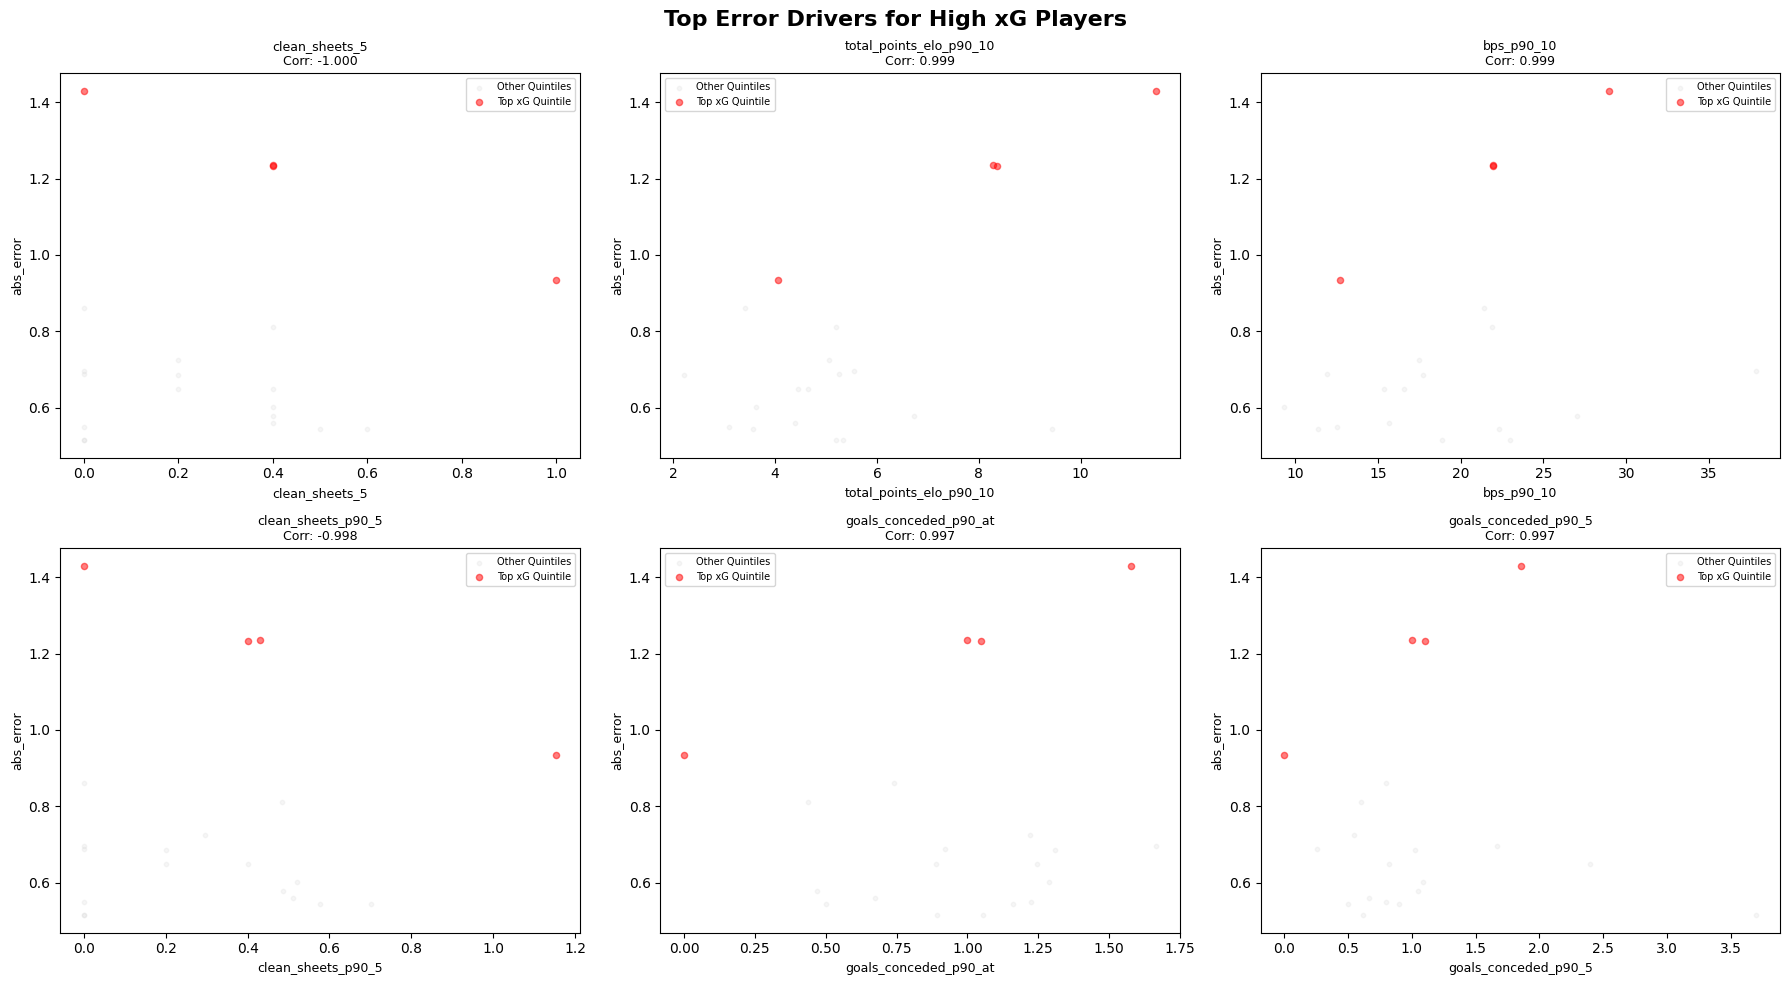


4. PREDICTION BIAS ANALYSIS

High xG Players:
  Over-predicted: 0 (0.0%)
  Under-predicted: 4 (100.0%)
  Mean Bias: -1.208

5. HIGH ERROR SUBGROUPS WITHIN TOP xG QUINTILE

Error by Position:
              mean  count
position                 
MID       1.208308      4

Error by Team Strength:
                   mean  count
team_strength                 
Weak           1.332580      2
Medium         0.934988      1
Strong         1.233082      1

Error by Opponent Strength:
                  mean  count
opp_strength                 
Weak          1.084035      2
Medium        1.234859      1
Strong        1.430301      1

Error by Home/Away:
              mean  count
was_home                 
false     0.934988      1
true      1.299414      3

6. SUGGESTED IMPROVEMENTS FOR HIGH xG PLAYERS

Recommendations:

1. ✓ Add INTERACTION term: 'clean_sheets_5' × 'total_points_elo_p90_10' (|Corr|: 0.842)


C:\Users\Chris\AppData\Local\Temp\ipykernel_9108\1128755521.py:147: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  team_errors = top_quintile.groupby('team_strength')[error_col].agg(['mean', 'count'])
C:\Users\Chris\AppData\Local\Temp\ipykernel_9108\1128755521.py:159: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  opp_errors = top_quintile.groupby('opp_strength')[error_col].agg(['mean', 'count'])


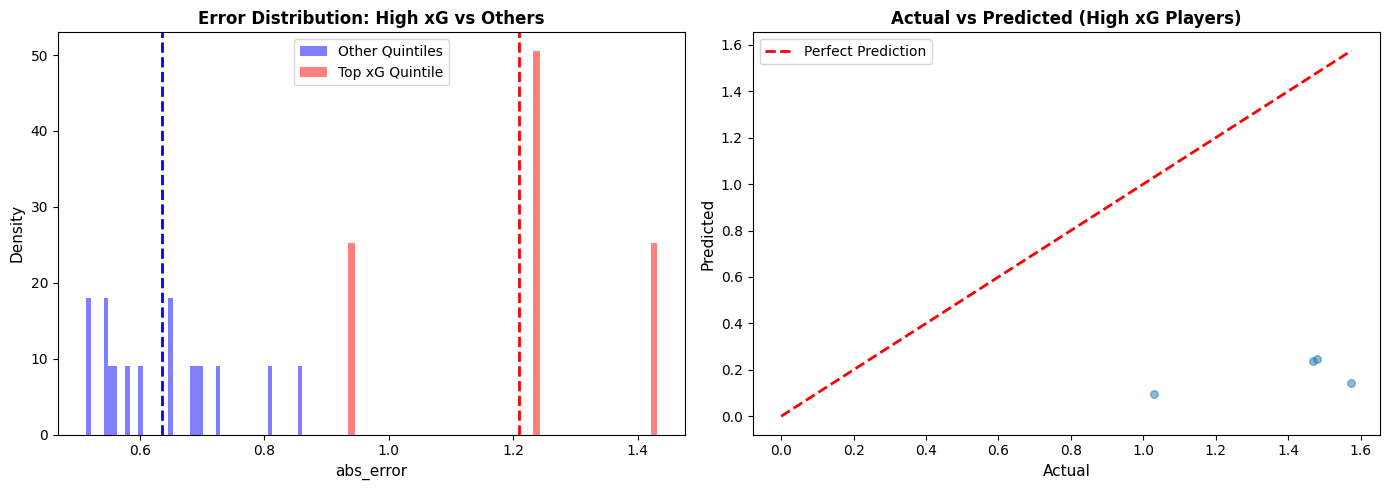

In [18]:
# USAGE:
results = analyze_high_xg_errors(MID_xG_errors, xg_col='expected_goals', error_col='abs_error')

Cleaned df size: 810/13902

Training Set Performance:
R² Score: 0.9250
RMSE: 9.8451
MAE: 7.3644

Test Set Performance:
R² Score: 0.6765
RMSE: 21.4132
MAE: 15.6867

Top 20 Feature Importances:
                                   feature  importance
                                 minutes_3    0.361848
                             minutes_elo_3    0.080945
                     xgoals_conceded_elo_5    0.022279
     xgoal_involvements_x_defensive_cont_3    0.019778
                       xassists_elo_p90_10    0.014562
                            xassists_elo_3    0.012523
                     xgoal_involvements_10    0.010456
                                 minutes_5    0.010097
                                 xgoals_10    0.007820
                defensive_cont_elo_p90sq_3    0.005817
                            bonus_p90sq_10    0.005739
                            opp_team_elo_3    0.005581
                         xassists_p90sq_at    0.005432
                        xgoals_concede

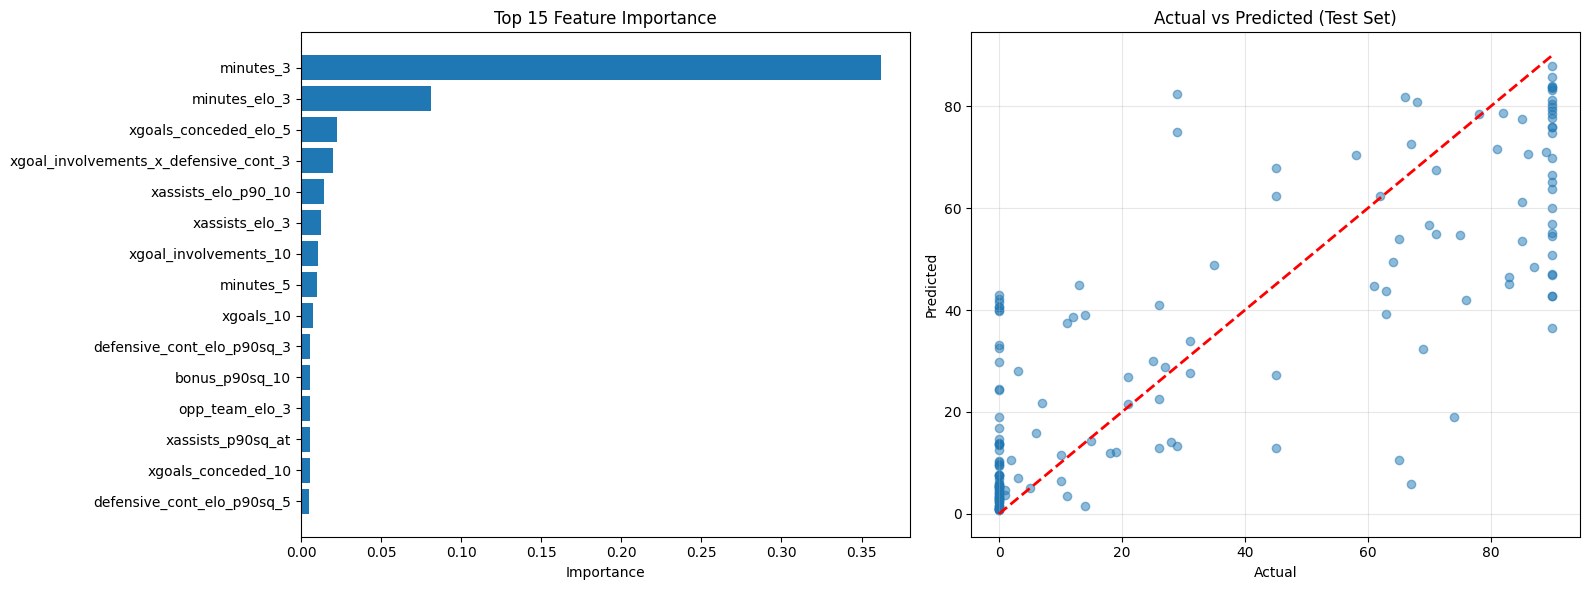

Cleaned df size: 3154/50011

Training Set Performance:
R² Score: 0.8444
RMSE: 14.9440
MAE: 11.5875

Test Set Performance:
R² Score: 0.4896
RMSE: 26.8087
MAE: 20.2675

Top 20 Feature Importances:
                                   feature  importance
                                 minutes_3    0.476862
                             minutes_elo_3    0.033762
                                    bps_10    0.028817
                            total_points_3    0.008525
     xgoal_involvements_x_defensive_cont_3    0.007632
                              opp_team_elo    0.007187
                                     bps_3    0.006854
    xgoal_involvements_x_defensive_cont_10    0.005414
                                     bps_5    0.005247
                       recoveries_p90sq_at    0.005215
xgoal_involvements_x_defensive_cont_p90_at    0.005179
                                  elo_diff    0.004983
                            opp_team_elo_5    0.004886
                           opp_team

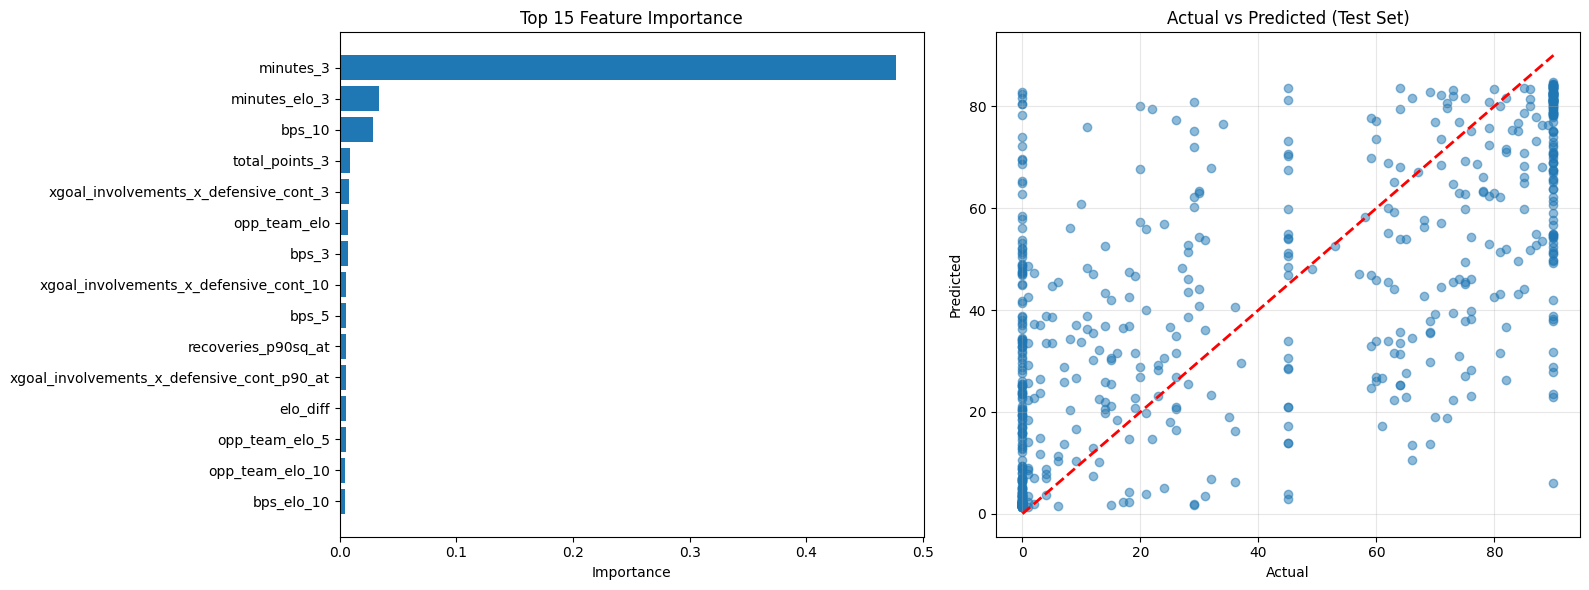

Cleaned df size: 2439/39301

Training Set Performance:
R² Score: 0.8567
RMSE: 15.8727
MAE: 11.4698

Test Set Performance:
R² Score: 0.4443
RMSE: 31.1644
MAE: 23.3628

Top 20 Feature Importances:
               feature  importance
             minutes_3    0.505031
         minutes_elo_3    0.017761
  opp_team_elo_p90sq_3    0.007809
        opp_team_elo_5    0.007291
   tackles_elo_p90sq_3    0.007188
                 bps_3    0.007042
          bps_p90sq_at    0.006785
    recoveries_p90sq_3    0.006441
           bps_p90sq_3    0.005798
 total_points_p90sq_at    0.005746
       opp_team_elo_10    0.005713
          opp_team_elo    0.005451
defensive_cont_p90sq_3    0.005372
recoveries_elo_p90sq_3    0.005289
        opp_team_elo_3    0.005258
      minutes_p90sq_at    0.005056
  goals_conceded_elo_5    0.005019
       tackles_p90sq_3    0.004528
            minutes_10    0.004374
   recoveries_p90sq_at    0.004277


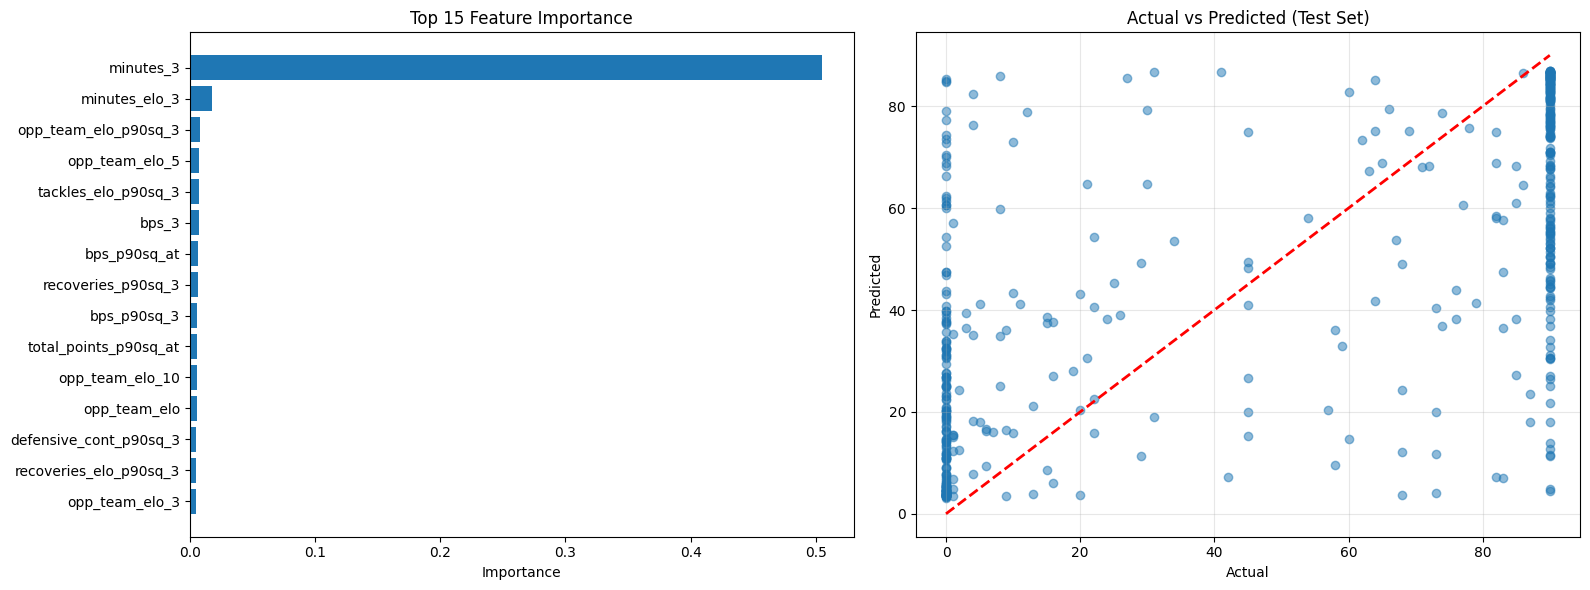

Cleaned df size: 441/8325

Training Set Performance:
R² Score: 0.9397
RMSE: 10.4095
MAE: 5.8037

Test Set Performance:
R² Score: 0.5572
RMSE: 26.5781
MAE: 13.9716

Top 20 Feature Importances:
               feature  importance
    recoveries_p90sq_3    0.173523
  opp_team_elo_p90sq_3    0.130533
      team_elo_p90sq_3    0.117154
opp_team_elo_elo_p90_3    0.058917
recoveries_elo_p90sq_3    0.042861
             minutes_3    0.042698
           bps_p90sq_3    0.018532
       bps_elo_p90sq_3    0.015351
    team_elo_elo_p90_3    0.013659
         minutes_elo_3    0.013618
             bps_elo_3    0.013150
        opp_team_elo_3    0.012297
     minutes_elo_p90_3    0.012119
       opp_team_elo_10    0.011187
          bps_p90sq_at    0.011050
          opp_team_elo    0.009951
       cbi_elo_p90sq_3    0.009408
     saves_elo_p90sq_3    0.009094
      minutes_p90sq_at    0.008586
  team_elo_elo_p90sq_3    0.008020


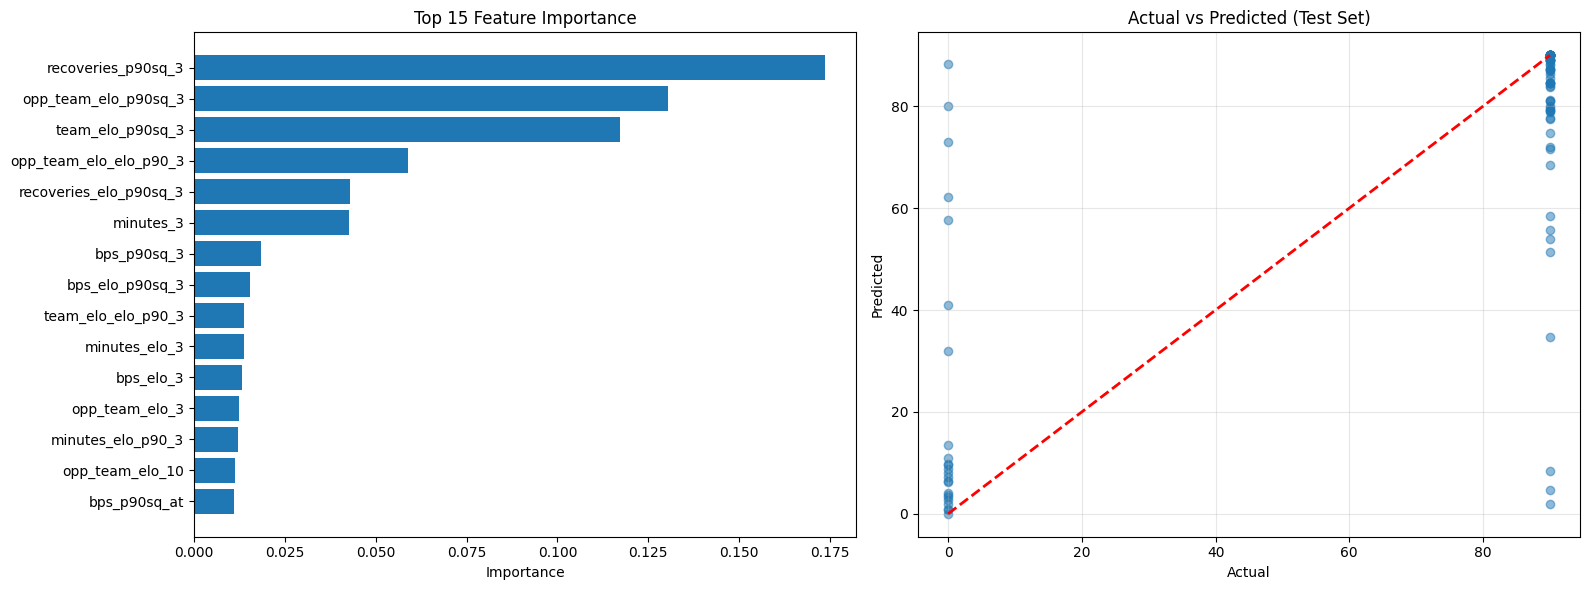

In [19]:
filtered = (df['player_season_minutes_total']>0)#&(df['total_points']<15)#&(df['minutes']>45)

if __name__ == "__main__":
    
    FWD_mins_predictor = FPLPredictor(
                data=df[filtered],
        target='minutes',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid
        )
    FWD_mins_predictor.fit()
    FWD_mins_predictor.plot_results()

    MID_mins_predictor = FPLPredictor(
        data=df[filtered],
        target='minutes',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid)
    MID_mins_predictor.fit()
    MID_mins_predictor.plot_results()

    DEF_mins_predictor = FPLPredictor(
        data=df[filtered],
        target='minutes',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid)
    DEF_mins_predictor.fit()
    DEF_mins_predictor.plot_results()

    GK_mins_predictor = FPLPredictor(
        data=df[filtered],
        target='minutes',
        positions={'GK'},
        columns_to_drop = cbi_defcon_cols)
    GK_mins_predictor.fit()
    GK_mins_predictor.plot_results()

target=expected_goals_per90, FWD_xG_predictor
Cleaned df size: 248/4193

Training Set Performance:
R² Score: 0.8553
RMSE: 0.1839
MAE: 0.1381

Test Set Performance:
R² Score: -0.4038
RMSE: 0.4538
MAE: 0.3550

Top 20 Feature Importances:
                              feature  importance
                 xgoal_involvements_5    0.061285
                             xgoals_5    0.046890
                       opp_team_elo_5    0.026389
                       bonus_p90sq_at    0.018611
                    xassists_p90sq_10    0.015593
          xgoals_conceded_elo_p90sq_5    0.015156
                          team_elo_10    0.014161
               xgoals_conceded_elo_10    0.013154
                    team_elo_p90sq_10    0.012539
            xgoals_conceded_elo_p90_5    0.012057
                    xgoals_conceded_3    0.011296
                      xgoals_p90sq_at    0.010499
                          cbi_p90sq_5    0.010478
              goals_conceded_p90sq_at    0.010329
              

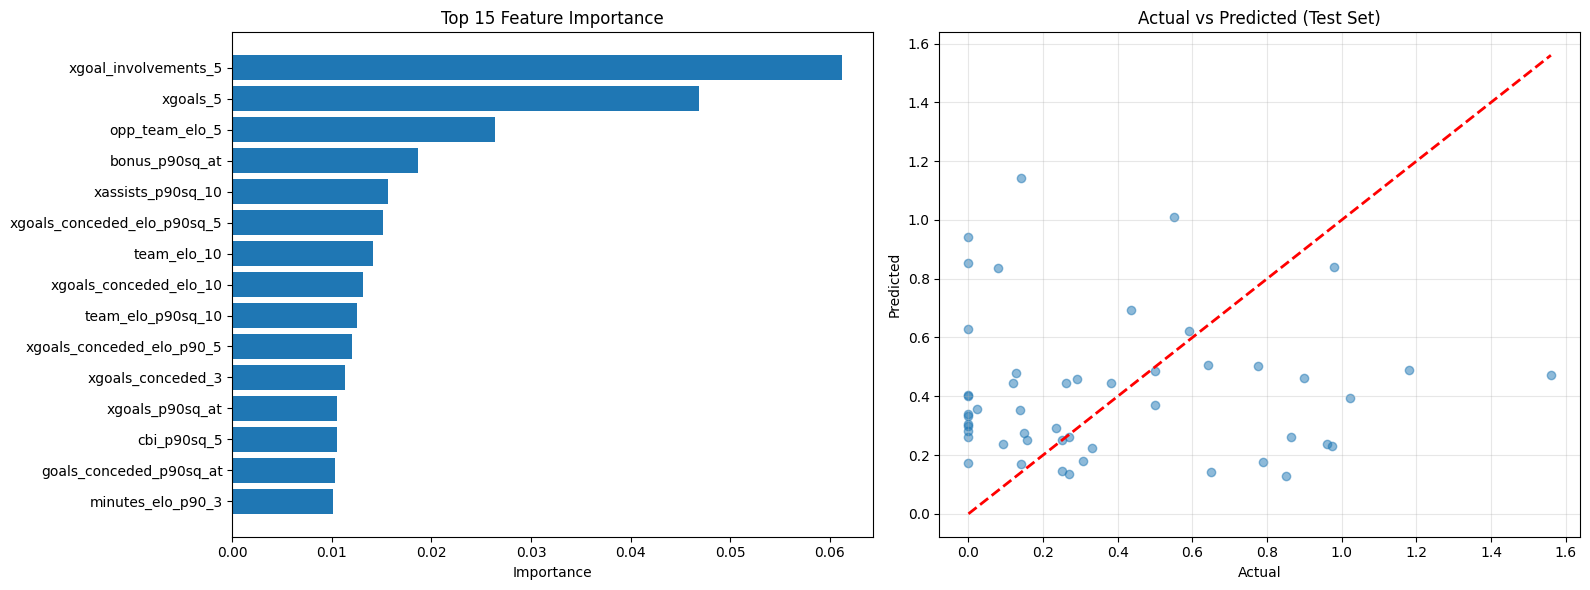

target=expected_goals_per90, MID_xG_predictor
Cleaned df size: 1234/17417

Training Set Performance:
R² Score: 0.7773
RMSE: 0.1053
MAE: 0.0789

Test Set Performance:
R² Score: 0.0357
RMSE: 0.2720
MAE: 0.1785

Top 20 Feature Importances:
                                   feature  importance
                                 xgoals_10    0.034696
                              opp_team_elo    0.023195
                  xgoal_involvements_elo_5    0.022579
                      xgoal_involvements_3    0.018934
                             xgoals_elo_10    0.014562
                       tackles_elo_p90sq_3    0.011256
                              cbi_p90sq_at    0.011167
                xgoal_involvements_p90sq_5    0.010422
xgoal_involvements_x_defensive_cont_p90_at    0.009880
                      xgoal_involvements_5    0.009873
                      total_points_p90sq_3    0.009463
                         xassists_p90sq_at    0.009382
                      opp_team_elo_p90sq_3    0.

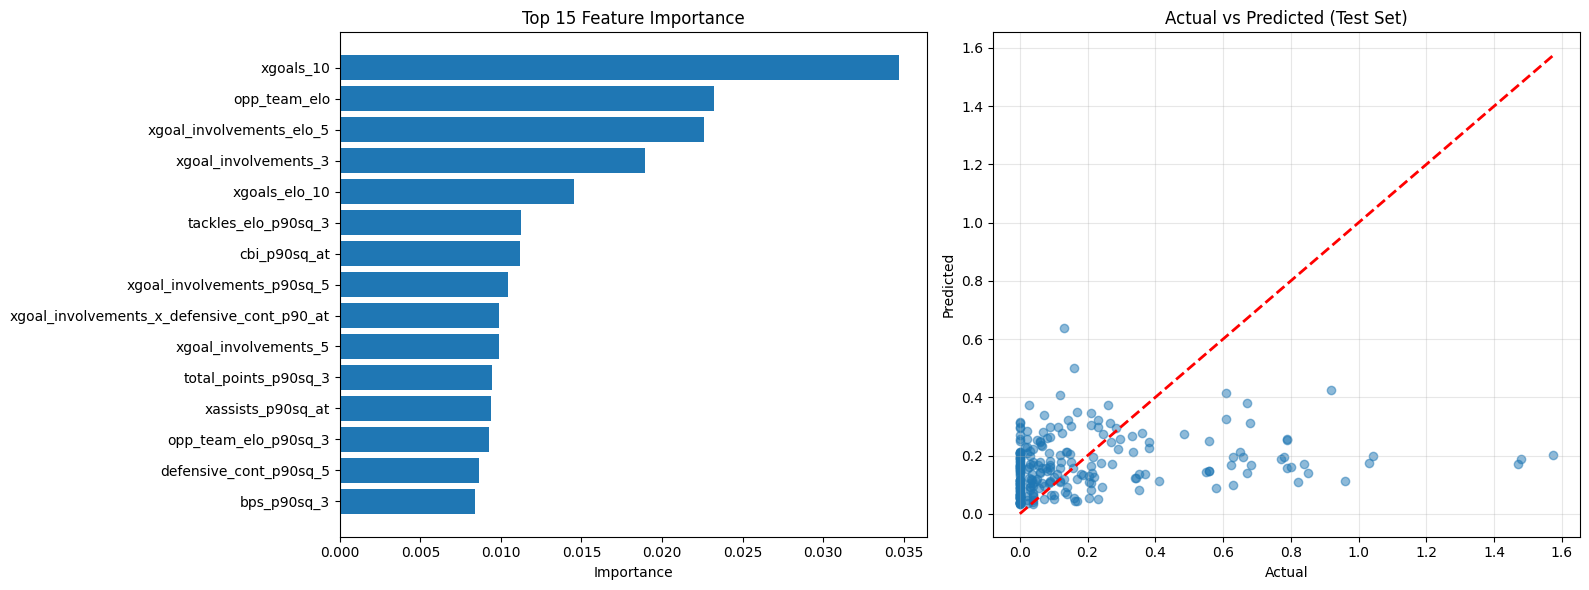

target=expected_goals_per90, DEF_xG_predictor
Cleaned df size: 1101/15364

Training Set Performance:
R² Score: 0.7203
RMSE: 0.0641
MAE: 0.0439

Test Set Performance:
R² Score: -0.0527
RMSE: 0.1428
MAE: 0.0762

Top 20 Feature Importances:
                      feature  importance
                 opp_team_elo    0.052252
                 bps_p90sq_at    0.039880
                     elo_diff    0.023803
    xgoal_involvements_elo_10    0.022476
              xgoals_p90sq_at    0.015459
        opp_team_elo_p90sq_at    0.015076
              opp_team_elo_10    0.014505
        total_points_p90sq_at    0.014268
xgoal_involvements_elo_p90_10    0.012432
  xgoal_involvements_p90sq_at    0.010877
             minutes_p90sq_at    0.009843
     xgoal_involvements_elo_3    0.009804
             tackles_p90sq_10    0.009756
         goals_conceded_elo_3    0.009431
           opp_team_elo_elo_5    0.009384
                xgoals_elo_10    0.009214
                   xassists_3    0.009154
      

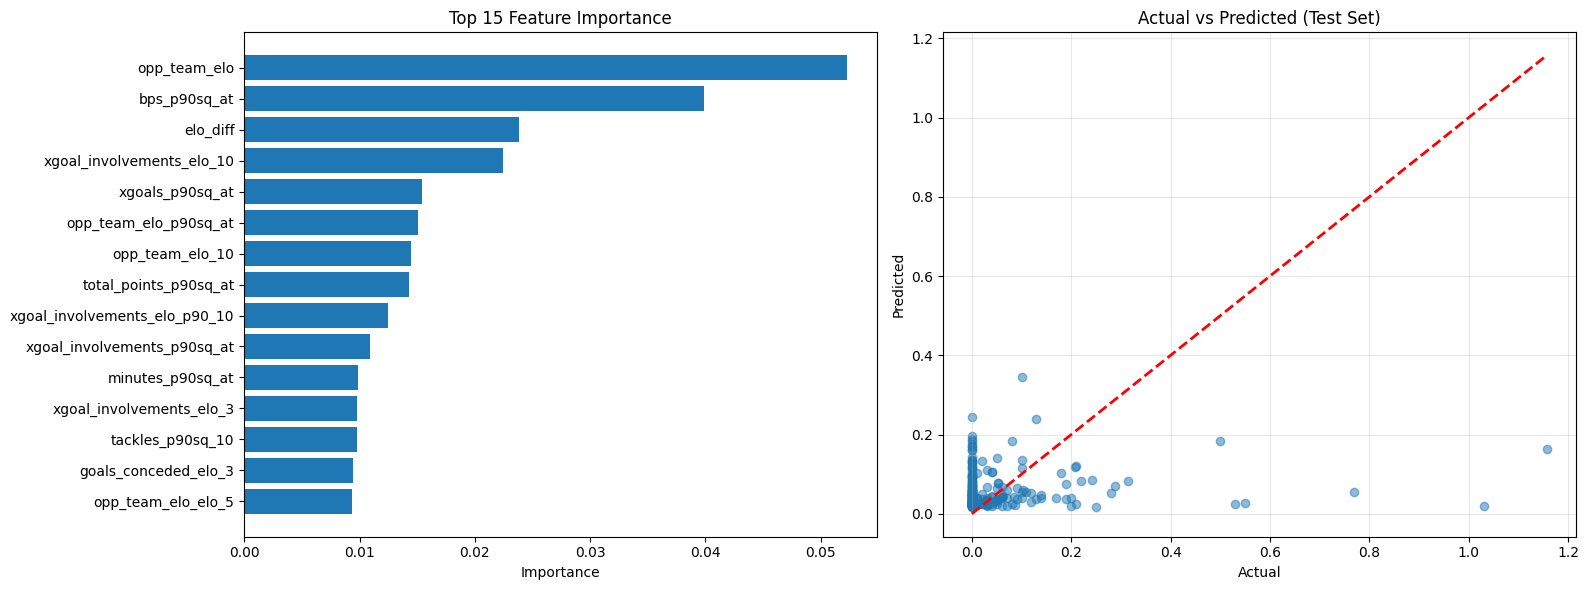

In [20]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>500)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=expected_goals_per90, FWD_xG_predictor")
    FWD_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid)
    FWD_xG_predictor.fit()
    FWD_xG_predictor.plot_results()

    print("target=expected_goals_per90, MID_xG_predictor")
    MID_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid)
    MID_xG_predictor.fit()
    MID_xG_predictor.plot_results()
    
    print("target=expected_goals_per90, DEF_xG_predictor")
    DEF_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid)
    DEF_xG_predictor.fit()
    DEF_xG_predictor.plot_results()

target=expected_assists_per90, FWD_xA_predictor
Cleaned df size: 248/4193

Training Set Performance:
R² Score: 0.7713
RMSE: 0.0390
MAE: 0.0252

Test Set Performance:
R² Score: -0.5010
RMSE: 0.0585
MAE: 0.0441

Top 20 Feature Importances:
                    feature  importance
xgoal_involvements_p90sq_10    0.039549
          goals_conceded_10    0.037508
     recoveries_elo_p90sq_3    0.035680
      opp_team_elo_p90sq_10    0.034914
                   elo_diff    0.032481
            xgoals_p90sq_10    0.030609
          team_elo_p90sq_10    0.018029
      total_points_p90sq_10    0.015548
             opp_team_elo_3    0.014474
         clean_sheets_elo_3    0.014317
   clean_sheets_elo_p90sq_3    0.013893
               opp_team_elo    0.011972
   xgoals_conceded_p90sq_10    0.011935
       clean_sheets_p90sq_3    0.011164
             bonus_p90sq_at    0.010885
   opp_team_elo_elo_p90sq_3    0.009703
           team_elo_p90sq_3    0.009626
  xgoals_conceded_elo_p90_3    0.009567
  

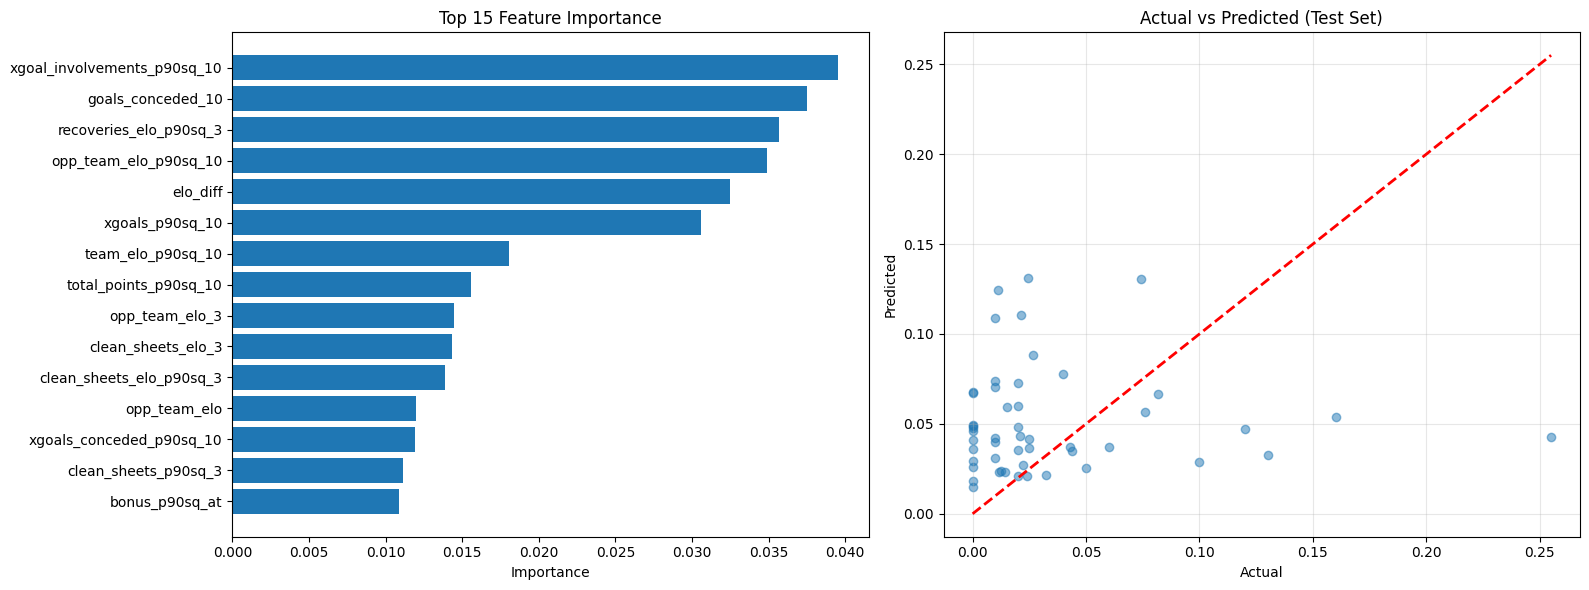

target=expected_assists_per90, MID_xA_predictor
Cleaned df size: 1234/17417

Training Set Performance:
R² Score: 0.7545
RMSE: 0.0722
MAE: 0.0554

Test Set Performance:
R² Score: 0.0283
RMSE: 0.1624
MAE: 0.1101

Top 20 Feature Importances:
                      feature  importance
    xgoal_involvements_elo_10    0.046913
                 opp_team_elo    0.044199
                     elo_diff    0.021202
               xassists_elo_5    0.014871
                 cbi_p90sq_10    0.012630
    xgoals_conceded_elo_p90_3    0.011807
                   xassists_5    0.011539
          xassists_elo_p90_10    0.011442
                  xassists_10    0.011267
             minutes_p90sq_at    0.011184
        opp_team_elo_p90sq_10    0.010209
        opp_team_elo_p90sq_at    0.009094
     xgoals_conceded_p90sq_at    0.009085
               xassists_elo_3    0.008907
xgoal_involvements_elo_p90_10    0.008882
                 cbi_p90sq_at    0.007708
                       bps_10    0.007483
     

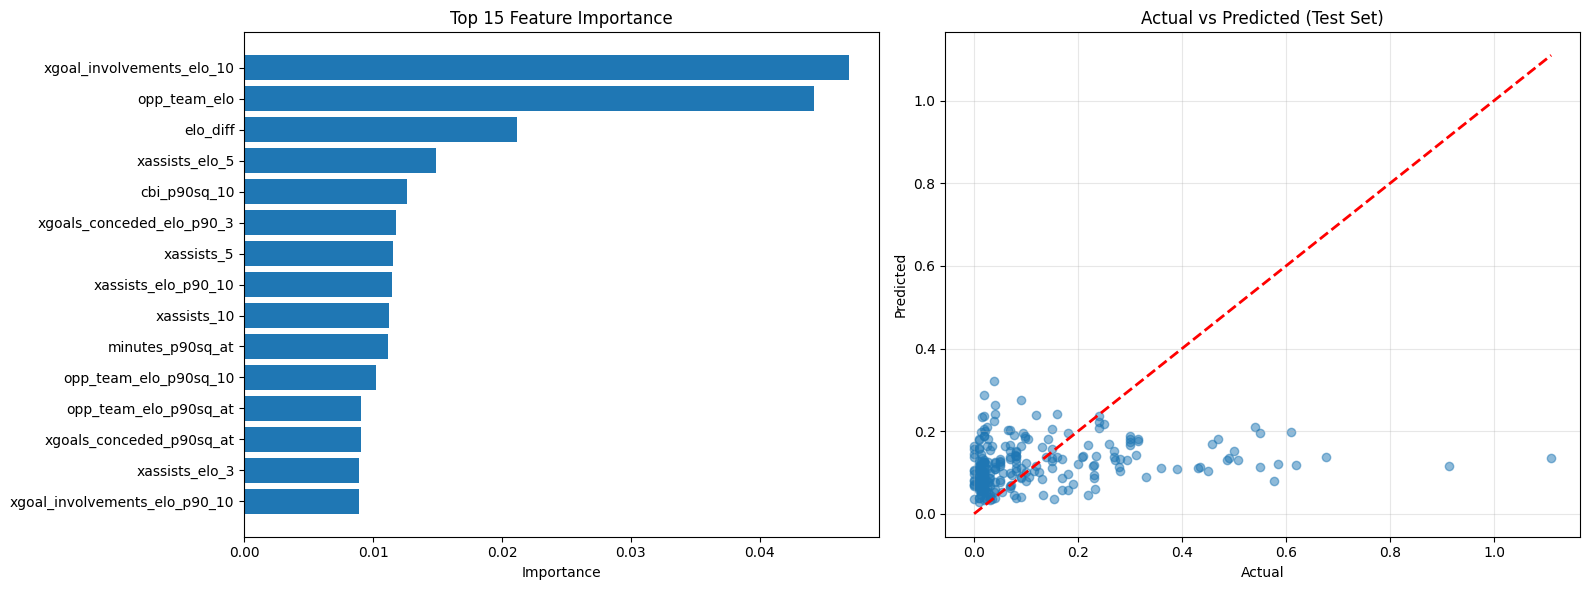

target=expected_assists_per90, DEF_xA_predictor
Cleaned df size: 1101/15364

Training Set Performance:
R² Score: 0.7675
RMSE: 0.0482
MAE: 0.0331

Test Set Performance:
R² Score: -0.0245
RMSE: 0.1171
MAE: 0.0700

Top 20 Feature Importances:
                    feature  importance
          xassists_p90sq_at    0.034017
               opp_team_elo    0.033761
            xassists_p90_10    0.028293
        recoveries_p90sq_at    0.024771
             total_points_5    0.013125
                      bps_5    0.012915
          xgoals_conceded_3    0.012902
           tackles_p90sq_at    0.011730
            opp_team_elo_10    0.011278
             opp_team_elo_3    0.011153
            tackles_p90sq_5    0.011092
        recoveries_p90sq_10    0.010837
xgoal_involvements_p90sq_at    0.010828
                  bps_elo_3    0.009575
             opp_team_elo_5    0.009499
                      bps_3    0.009434
    recoveries_elo_p90sq_10    0.008967
       tackles_elo_p90sq_10    0.008814


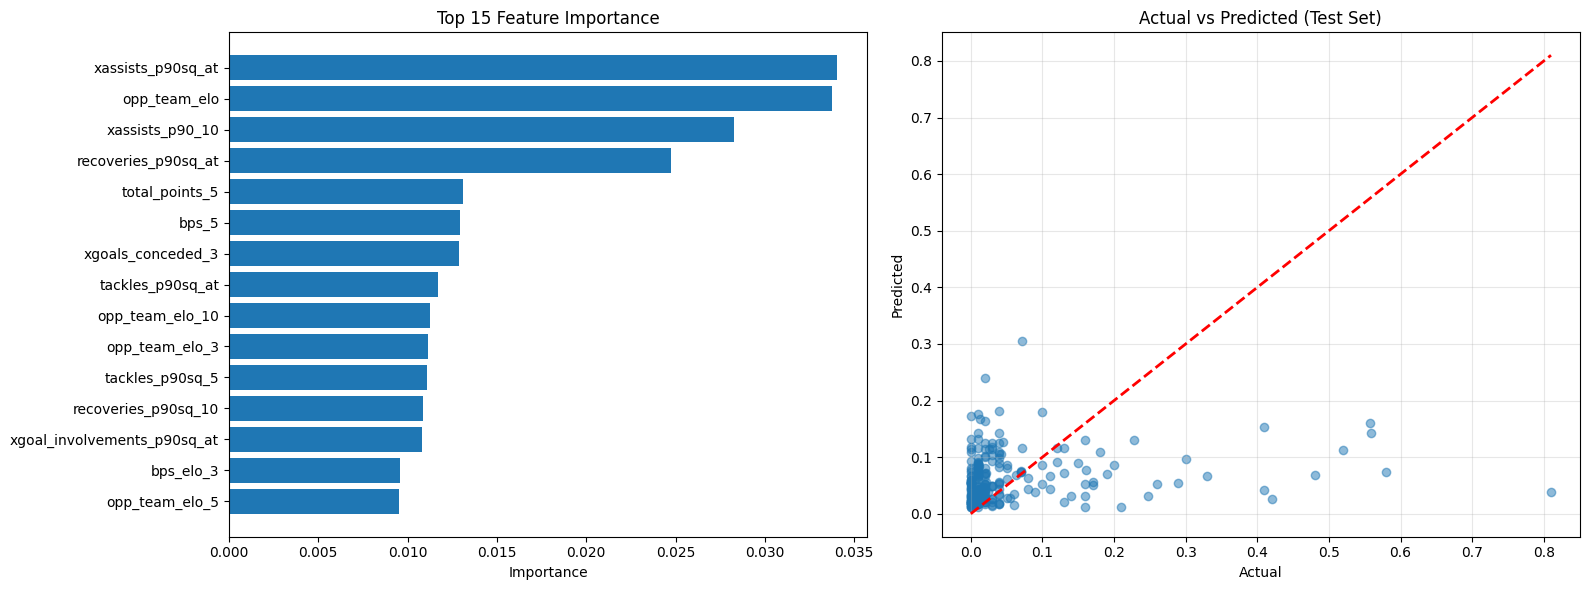

In [21]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>500)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=expected_assists_per90, FWD_xA_predictor")
    FWD_xA_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_assists_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols)
    FWD_xA_predictor.fit()
    FWD_xA_predictor.plot_results()

    print("target=expected_assists_per90, MID_xA_predictor")
    MID_xA_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_assists_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols)
    MID_xA_predictor.fit()
    MID_xA_predictor.plot_results()
    
    print("target=expected_assists_per90, DEF_xA_predictor")
    DEF_xA_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_assists_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols)
    DEF_xA_predictor.fit()
    DEF_xA_predictor.plot_results()

target=expected_goals_conceded_per90, FWD_xGC_predictor
Cleaned df size: 248/4193

Training Set Performance:
R² Score: 0.8484
RMSE: 0.3191
MAE: 0.2565

Test Set Performance:
R² Score: 0.0201
RMSE: 0.7256
MAE: 0.6059

Top 20 Feature Importances:
                   feature  importance
                  elo_diff    0.108446
              opp_team_elo    0.039144
            opp_team_elo_3    0.037562
       recoveries_p90sq_at    0.014106
      opp_team_elo_p90sq_3    0.013882
   xgoals_conceded_p90sq_3    0.011500
         team_elo_p90sq_at    0.011264
     xgoals_conceded_p90_3    0.010756
           tackles_p90sq_3    0.009499
                 minutes_5    0.009170
            opp_team_elo_5    0.008568
 xgoal_involvements_p90_10    0.008414
    defensive_cont_p90sq_5    0.008279
                team_elo_3    0.008084
       minutes_elo_p90sq_3    0.008076
         team_elo_p90sq_10    0.007937
                xassists_3    0.007834
           xgoals_p90sq_10    0.007576
          team

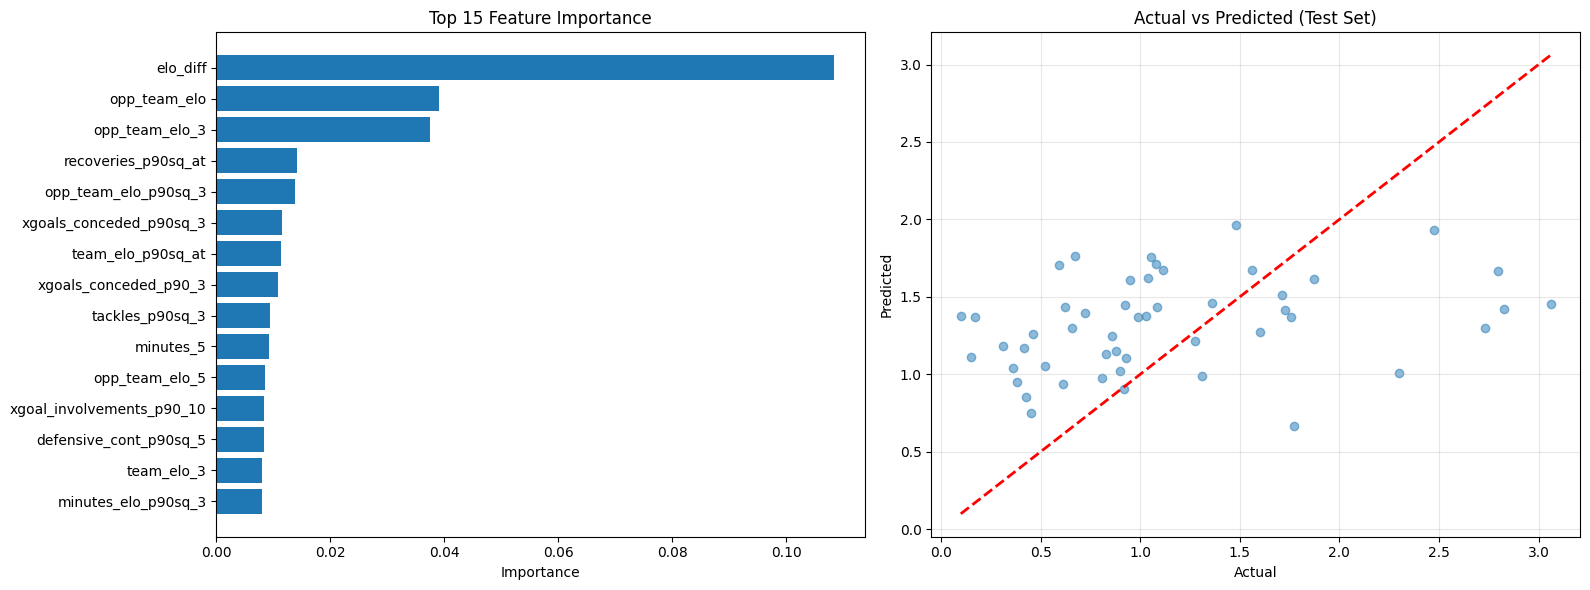

target=expected_goals_conceded_per90, MID_xGC_predictor
Cleaned df size: 1234/17417

Training Set Performance:
R² Score: 0.8507
RMSE: 0.3123
MAE: 0.2545

Test Set Performance:
R² Score: 0.3687
RMSE: 0.5612
MAE: 0.4661

Top 20 Feature Importances:
                   feature  importance
                  elo_diff    0.198674
            opp_team_elo_3    0.053593
              opp_team_elo    0.045217
                  team_elo    0.031209
           opp_team_elo_10    0.026774
            opp_team_elo_5    0.026004
                team_elo_3    0.023930
                team_elo_5    0.013730
        opp_team_elo_elo_5    0.010844
            team_elo_elo_5    0.009845
            team_elo_elo_3    0.008892
goals_conceded_elo_p90sq_5    0.008464
        opp_team_elo_elo_3    0.006736
               team_elo_10    0.006682
         xgoals_conceded_3    0.006577
     clean_sheets_p90sq_at    0.006221
           team_elo_elo_10    0.006099
    defensive_cont_p90sq_5    0.005881
   goals_con

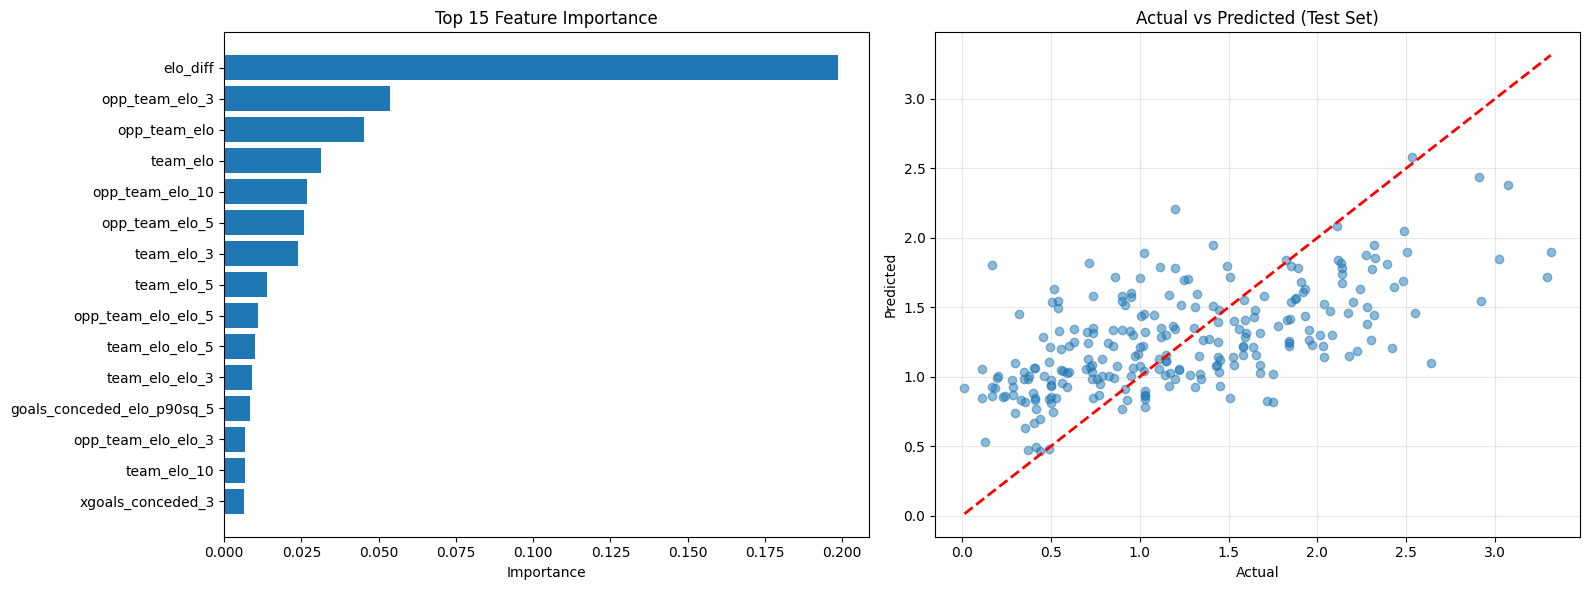

target=expected_goals_conceded_per90, DEF_xGC_predictor
Cleaned df size: 1101/15364

Training Set Performance:
R² Score: 0.8698
RMSE: 0.3030
MAE: 0.2439

Test Set Performance:
R² Score: 0.4283
RMSE: 0.5604
MAE: 0.4515

Top 20 Feature Importances:
                    feature  importance
                   elo_diff    0.173133
             opp_team_elo_3    0.065978
               opp_team_elo    0.059115
                   team_elo    0.044070
                 team_elo_3    0.026689
             opp_team_elo_5    0.024267
                 team_elo_5    0.021605
            opp_team_elo_10    0.013487
                team_elo_10    0.012886
         clean_sheets_elo_3    0.011855
         opp_team_elo_elo_5    0.010962
             team_elo_elo_5    0.009576
         opp_team_elo_elo_3    0.009319
     goals_conceded_p90sq_5    0.008940
 goals_conceded_elo_p90sq_5    0.008855
          xgoals_conceded_3    0.008022
      xgoals_conceded_p90_5    0.007918
goals_conceded_elo_p90sq_10    0.

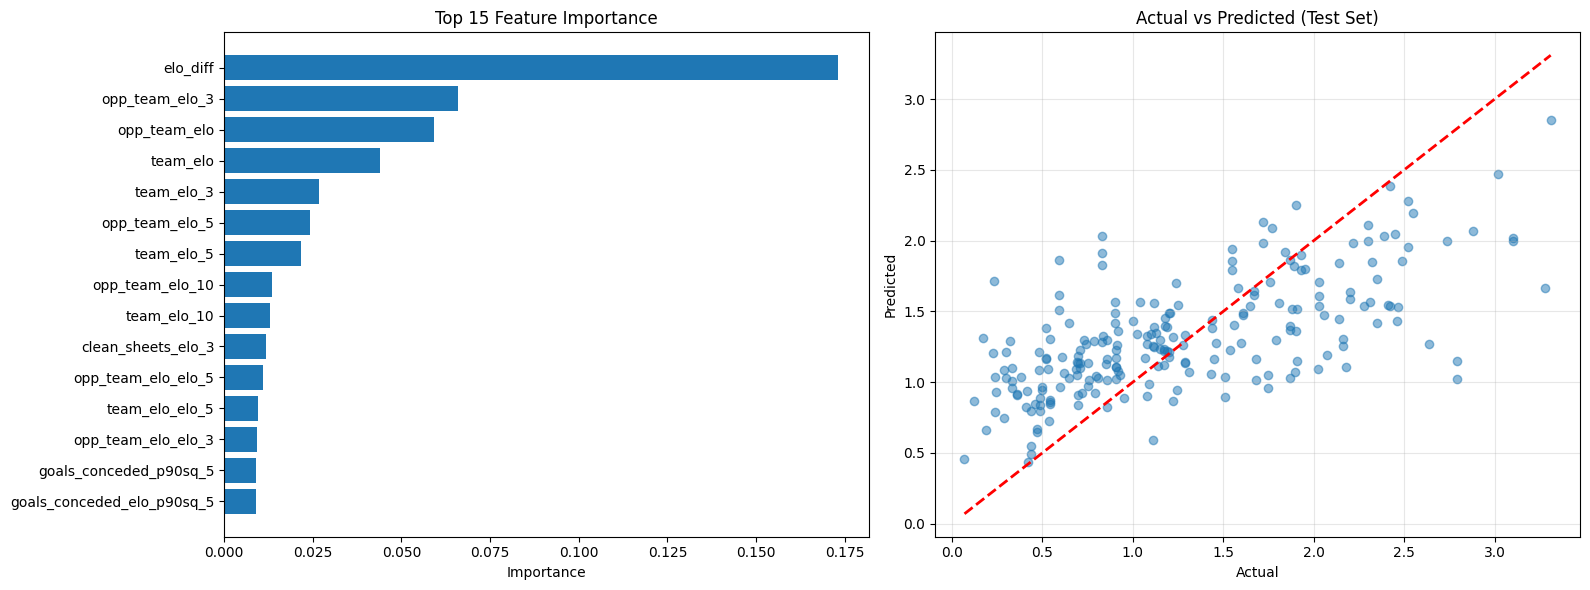

target=expected_goals_conceded_per90, GK_xGC_predictor
Cleaned df size: 272/3739

Training Set Performance:
R² Score: 0.8495
RMSE: 0.3336
MAE: 0.2664

Test Set Performance:
R² Score: 0.0488
RMSE: 0.5945
MAE: 0.5089

Top 20 Feature Importances:
                     feature  importance
                    elo_diff    0.157869
              opp_team_elo_3    0.039759
                opp_team_elo    0.038976
           saves_elo_p90sq_3    0.021903
             opp_team_elo_10    0.018073
          recoveries_p90sq_3    0.016164
 xgoals_conceded_elo_p90sq_5    0.014772
              opp_team_elo_5    0.014181
     xgoals_conceded_p90sq_5    0.013034
                 team_elo_10    0.011731
             cbi_elo_p90sq_3    0.011730
    xgoals_conceded_p90sq_10    0.011483
xgoals_conceded_elo_p90sq_10    0.010483
      recoveries_elo_p90sq_3    0.010353
            team_elo_p90sq_3    0.010235
                cbi_p90sq_at    0.009849
            cbi_elo_p90sq_10    0.009406
           xgoals_

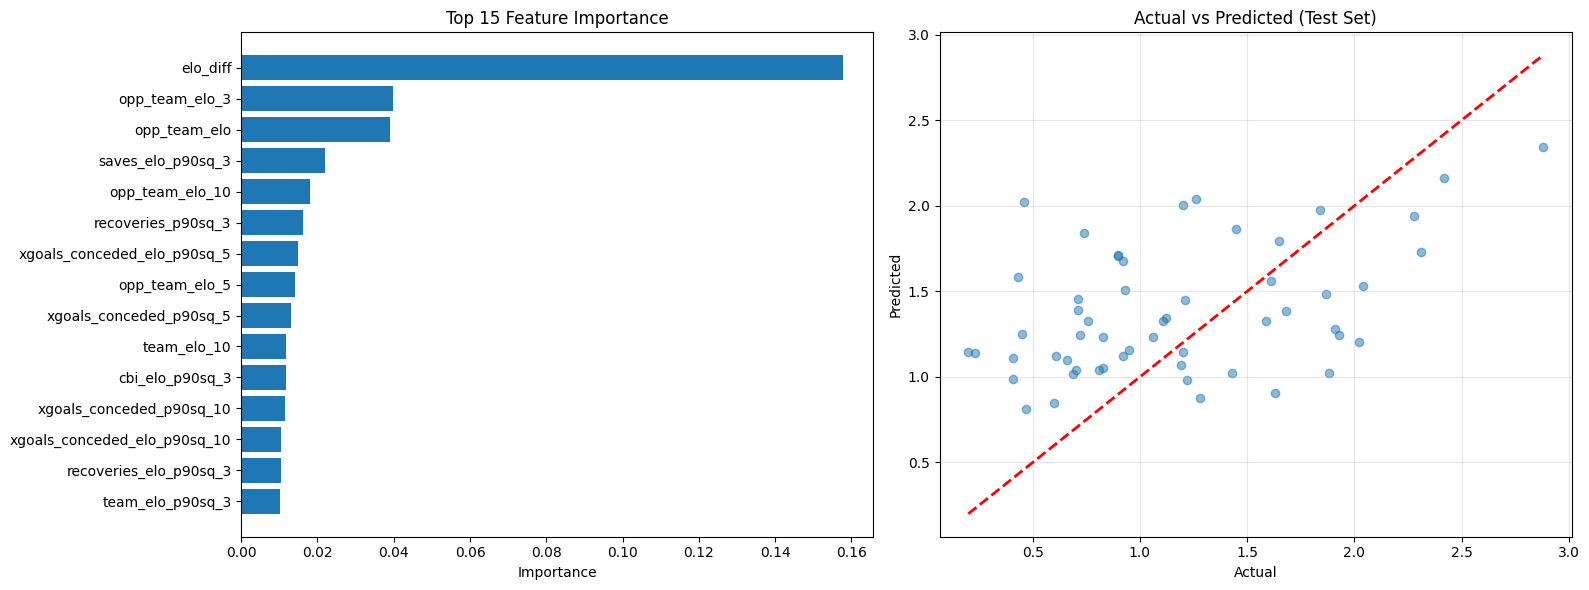

In [22]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>500)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=expected_goals_conceded_per90, FWD_xGC_predictor")
    FWD_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols)
    FWD_xGC_predictor.fit()
    FWD_xGC_predictor.plot_results()

    print("target=expected_goals_conceded_per90, MID_xGC_predictor")
    MID_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols)
    MID_xGC_predictor.fit()
    MID_xGC_predictor.plot_results()
    
    print("target=expected_goals_conceded_per90, DEF_xGC_predictor")
    DEF_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols)
    DEF_xGC_predictor.fit()
    DEF_xGC_predictor.plot_results()

    print("target=expected_goals_conceded_per90, GK_xGC_predictor")
    GK_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'GK'},
        columns_to_drop = cbi_defcon_cols)
    GK_xGC_predictor.fit()
    GK_xGC_predictor.plot_results()

target=bps_per90, FWD_bps_predictor
Cleaned df size: 248/4193

Training Set Performance:
R² Score: 0.8102
RMSE: 7.9300
MAE: 6.2271

Test Set Performance:
R² Score: -0.0839
RMSE: 19.5247
MAE: 14.5621

Top 20 Feature Importances:
                    feature  importance
          minutes_elo_p90_3    0.046935
        minutes_elo_p90sq_5    0.022340
    goals_conceded_p90sq_10    0.019096
      clean_sheets_p90sq_10    0.016993
       xgoal_involvements_5    0.016851
                   elo_diff    0.013855
        minutes_elo_p90sq_3    0.013159
                   xgoals_5    0.012676
  goals_conceded_elo_p90_10    0.011766
            cbi_elo_p90sq_3    0.011211
                team_elo_10    0.010590
  xgoal_involvements_elo_10    0.010555
goals_conceded_elo_p90sq_10    0.010543
      xgoals_conceded_p90_3    0.009606
                 team_elo_5    0.009492
            xassists_p90_10    0.009450
      xgoals_conceded_elo_5    0.009409
               opp_team_elo    0.009397
            

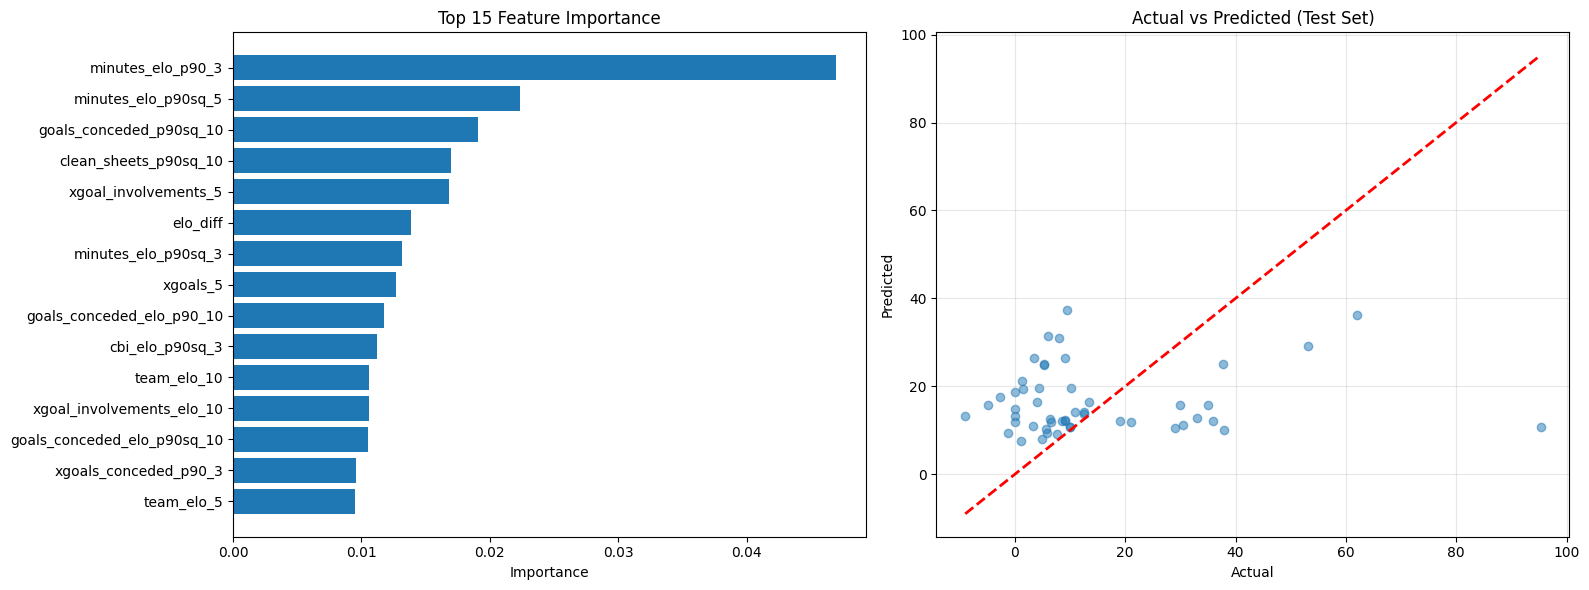

target=bps_per90, MID_bps_predictor
Cleaned df size: 1234/17417

Training Set Performance:
R² Score: 0.6547
RMSE: 6.8815
MAE: 5.4439

Test Set Performance:
R² Score: -0.0114
RMSE: 12.2738
MAE: 8.9113

Top 20 Feature Importances:
                                   feature  importance
                                  elo_diff    0.051280
                              opp_team_elo    0.025443
                     opp_team_elo_p90sq_10    0.015770
                  clean_sheets_elo_p90sq_5    0.013214
                    defensive_cont_p90sq_5    0.012400
                               bps_p90sq_5    0.010809
     xgoal_involvements_x_defensive_cont_3    0.010568
xgoal_involvements_x_defensive_cont_p90_10    0.009947
                      opp_team_elo_p90sq_5    0.009712
                     opp_team_elo_p90sq_at    0.009632
                 xgoals_conceded_elo_p90_3    0.009231
                              bps_p90sq_at    0.008791
                    recoveries_elo_p90sq_3    0.008497
 

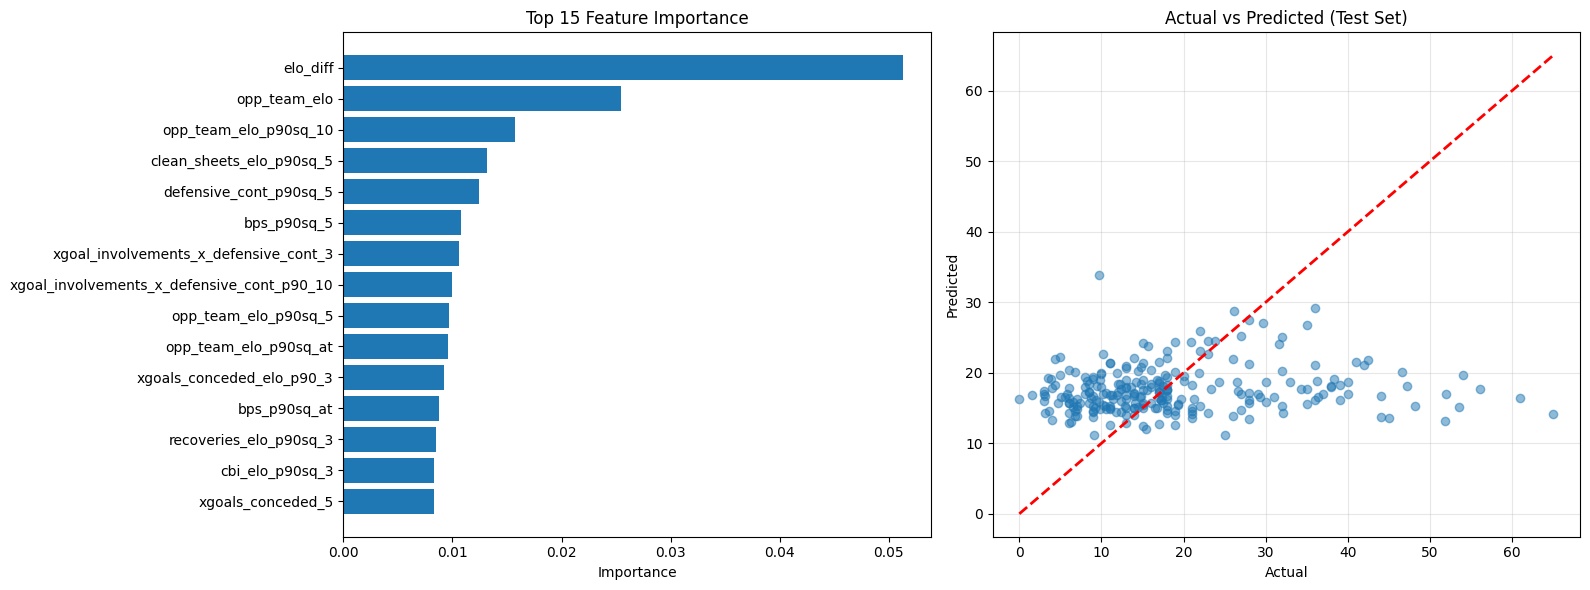

target=bps_per90, DEF_bps_predictor
Cleaned df size: 1101/15364

Training Set Performance:
R² Score: 0.8250
RMSE: 5.1914
MAE: 4.1460

Test Set Performance:
R² Score: 0.1952
RMSE: 12.1567
MAE: 9.1024

Top 20 Feature Importances:
                   feature  importance
                  elo_diff    0.125688
                team_elo_5    0.021953
            opp_team_elo_5    0.019465
              opp_team_elo    0.018546
           opp_team_elo_10    0.017570
            opp_team_elo_3    0.013700
            team_elo_elo_3    0.012080
            team_elo_elo_5    0.011433
                team_elo_3    0.010782
           team_elo_elo_10    0.010155
       tackles_elo_p90sq_3    0.008559
                  team_elo    0.008413
goals_conceded_elo_p90sq_3    0.008113
   xgoals_conceded_p90sq_3    0.008031
   recoveries_elo_p90sq_10    0.007712
               team_elo_10    0.007663
      goals_conceded_elo_3    0.007644
       recoveries_p90sq_at    0.006721
    recoveries_elo_p90sq_3    0

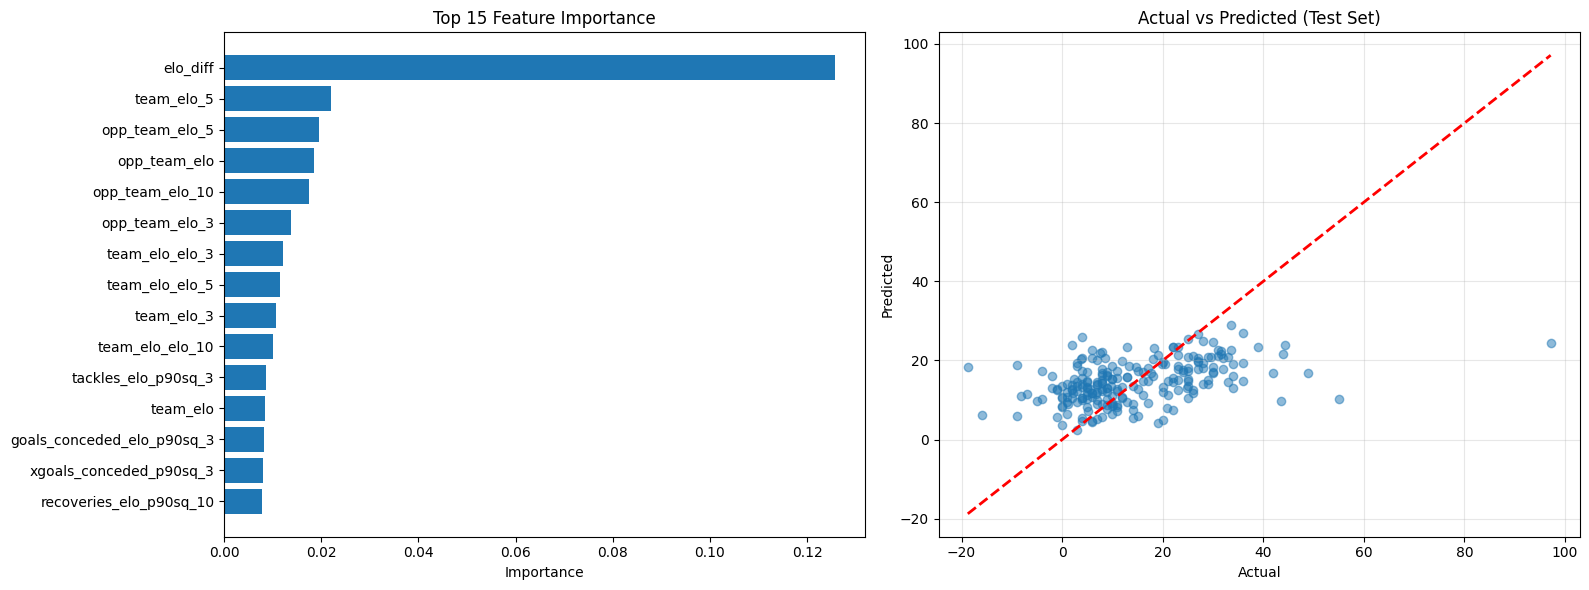

target=bps_per90, GK_bps_predictor
Cleaned df size: 272/3739

Training Set Performance:
R² Score: 0.8348
RMSE: 4.0310
MAE: 3.2976

Test Set Performance:
R² Score: -0.1183
RMSE: 11.2513
MAE: 9.4981

Top 20 Feature Importances:
                    feature  importance
      opp_team_elo_p90sq_10    0.027352
               cbi_p90sq_at    0.025905
                   elo_diff    0.022688
       total_points_p90sq_3    0.021642
 goals_conceded_elo_p90sq_3    0.020943
             opp_team_elo_5    0.020153
             opp_team_elo_3    0.018524
    xgoals_conceded_p90sq_3    0.017826
 goals_conceded_elo_p90sq_5    0.017228
            opp_team_elo_10    0.017078
   xgoals_conceded_p90sq_at    0.015987
         recoveries_p90sq_3    0.015900
   total_points_elo_p90sq_3    0.014143
goals_conceded_elo_p90sq_10    0.014105
           cbi_elo_p90sq_10    0.013968
     goals_conceded_p90sq_5    0.013957
xgoals_conceded_elo_p90sq_3    0.013944
               opp_team_elo    0.013895
       opp_tea

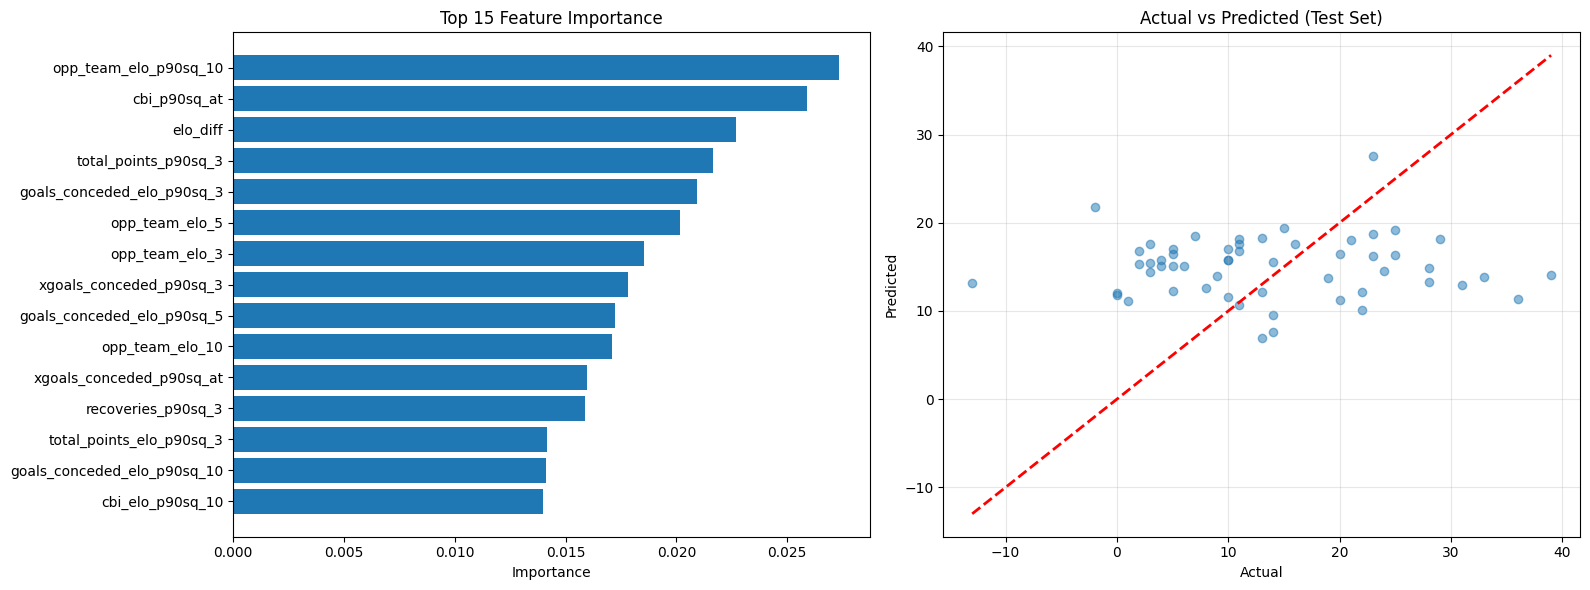

In [23]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>500)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=bps_per90, FWD_bps_predictor")
    FWD_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90', # try: 'bonus_per90'
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols)
    FWD_bps_predictor.fit()
    FWD_bps_predictor.plot_results()

    print("target=bps_per90, MID_bps_predictor")
    MID_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols)
    MID_bps_predictor.fit()
    MID_bps_predictor.plot_results()
    
    print("target=bps_per90, DEF_bps_predictor")
    DEF_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols)
    DEF_bps_predictor.fit()
    DEF_bps_predictor.plot_results()

    print("target=bps_per90, GK_bps_predictor")
    GK_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90',
        positions={'GK'},
        columns_to_drop = cbi_defcon_cols)
    GK_bps_predictor.fit()
    GK_bps_predictor.plot_results()

target=saves_per90, GK_saves_predictor
Cleaned df size: 299/3901

Training Set Performance:
R² Score: 0.8474
RMSE: 0.6581
MAE: 0.5316

Test Set Performance:
R² Score: 0.0134
RMSE: 1.7047
MAE: 1.3844

Top 20 Feature Importances:
                   feature  importance
                  elo_diff    0.076235
            opp_team_elo_3    0.049253
              opp_team_elo    0.035124
      opp_team_elo_p90sq_5    0.022849
          team_elo_p90sq_5    0.019453
     team_elo_elo_p90sq_10    0.018382
               cbi_p90sq_5    0.017821
                team_elo_5    0.015918
              bps_p90sq_at    0.013418
               team_elo_10    0.013270
      opp_team_elo_p90sq_3    0.011583
   xgoals_conceded_p90sq_5    0.011338
goals_conceded_elo_p90sq_5    0.011250
                    cbi_at    0.010965
            opp_team_elo_5    0.010732
               saves_elo_3    0.009714
           cbi_elo_p90sq_5    0.009555
         recoveries_p90_at    0.009527
   goals_conceded_p90sq_at    0

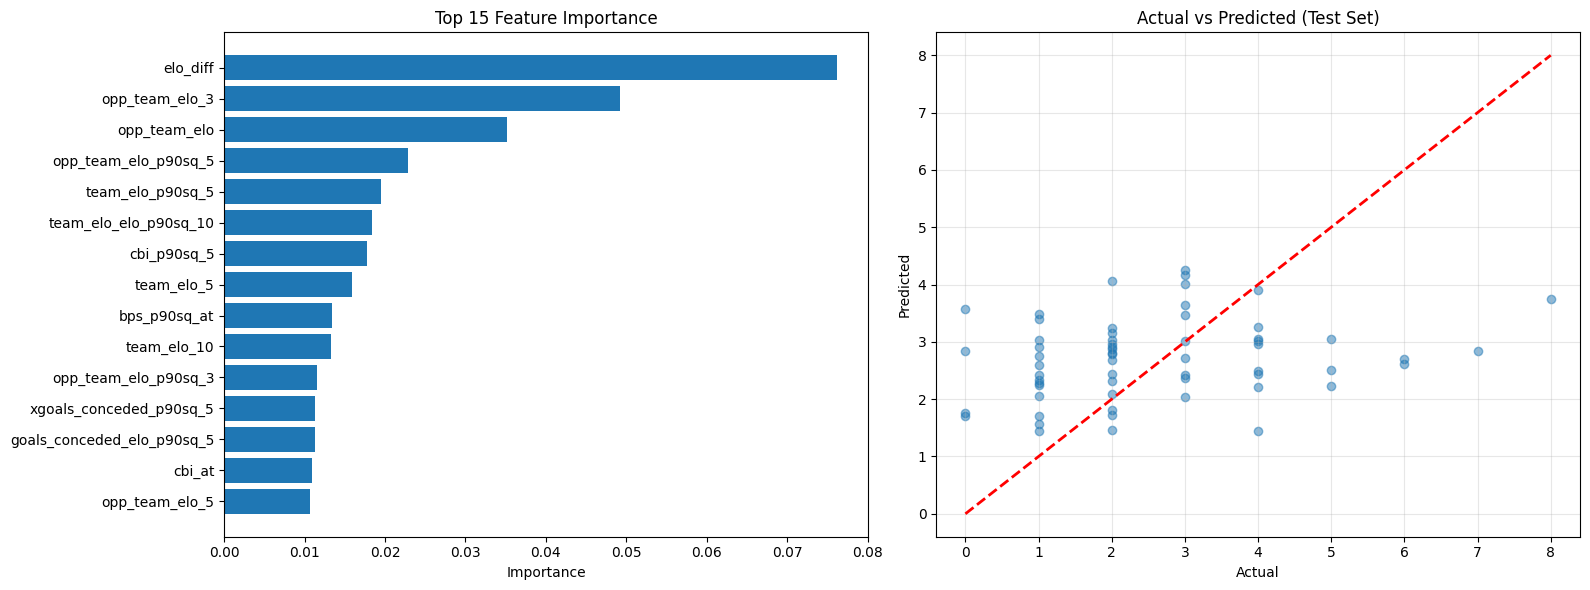

In [24]:
#shots saved
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>0)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=saves_per90, GK_saves_predictor")
    GK_saves_predictor = FPLPredictor(
    data=df[filtered],
    target='saves_per90',
    positions={'GK'})
    GK_saves_predictor.fit()
    GK_saves_predictor.plot_results()

target=defensive_contribution_per90, FWD_defcon_predictor
Cleaned df size: 330/4803

Training Set Performance:
R² Score: 0.8270
RMSE: 1.1543
MAE: 0.8854

Test Set Performance:
R² Score: -0.0491
RMSE: 2.9551
MAE: 2.0869

Top 20 Feature Importances:
                  feature  importance
           xassists_elo_3    0.045617
           opp_team_elo_5    0.024038
          opp_team_elo_10    0.022028
               xassists_3    0.016493
     goals_conceded_p90_5    0.015770
              team_elo_10    0.014902
        xgoals_conceded_3    0.013782
                 team_elo    0.013720
           opp_team_elo_3    0.013646
    clean_sheets_p90sq_at    0.013526
      minutes_elo_p90sq_5    0.012542
        xassists_p90sq_at    0.011104
     defensive_cont_elo_3    0.011018
     defensive_cont_elo_5    0.010239
     minutes_elo_p90sq_10    0.009193
         defensive_cont_3    0.009084
clean_sheets_elo_p90sq_10    0.008217
             opp_team_elo    0.008185
  goals_conceded_p90sq_at    0

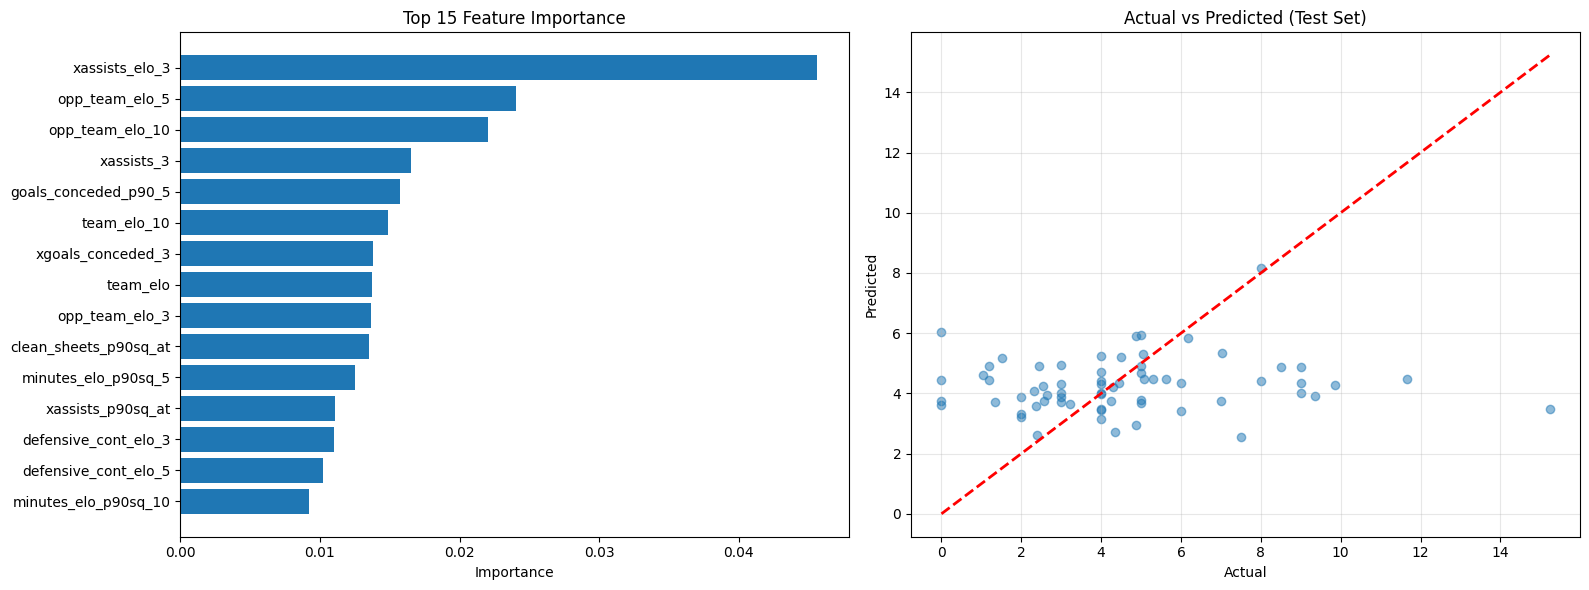

target=defensive_contribution_per90, MID_defcon_predictor
Cleaned df size: 1550/19813

Training Set Performance:
R² Score: 0.7942
RMSE: 1.8345
MAE: 1.4750

Test Set Performance:
R² Score: 0.1499
RMSE: 4.0443
MAE: 3.1124

Top 20 Feature Importances:
                feature  importance
             cbi_p90_10    0.023731
       tackles_p90sq_10    0.020408
             tackles_at    0.020195
defensive_cont_p90sq_10    0.018940
            cbi_p90sq_3    0.014312
  defensive_cont_p90_10    0.013080
  goals_scored_p90sq_at    0.012658
 defensive_cont_p90sq_5    0.012249
           opp_team_elo    0.010781
         bonus_p90sq_at    0.009043
                 cbi_at    0.008588
      xassists_p90sq_at    0.008299
         opp_team_elo_3    0.008252
          xgoals_p90_10    0.008155
               elo_diff    0.007670
        xgoals_p90sq_10    0.007207
   opp_team_elo_p90sq_5    0.007149
       defensive_cont_3    0.006943
        opp_team_elo_10    0.006911
         opp_team_elo_5    0.00

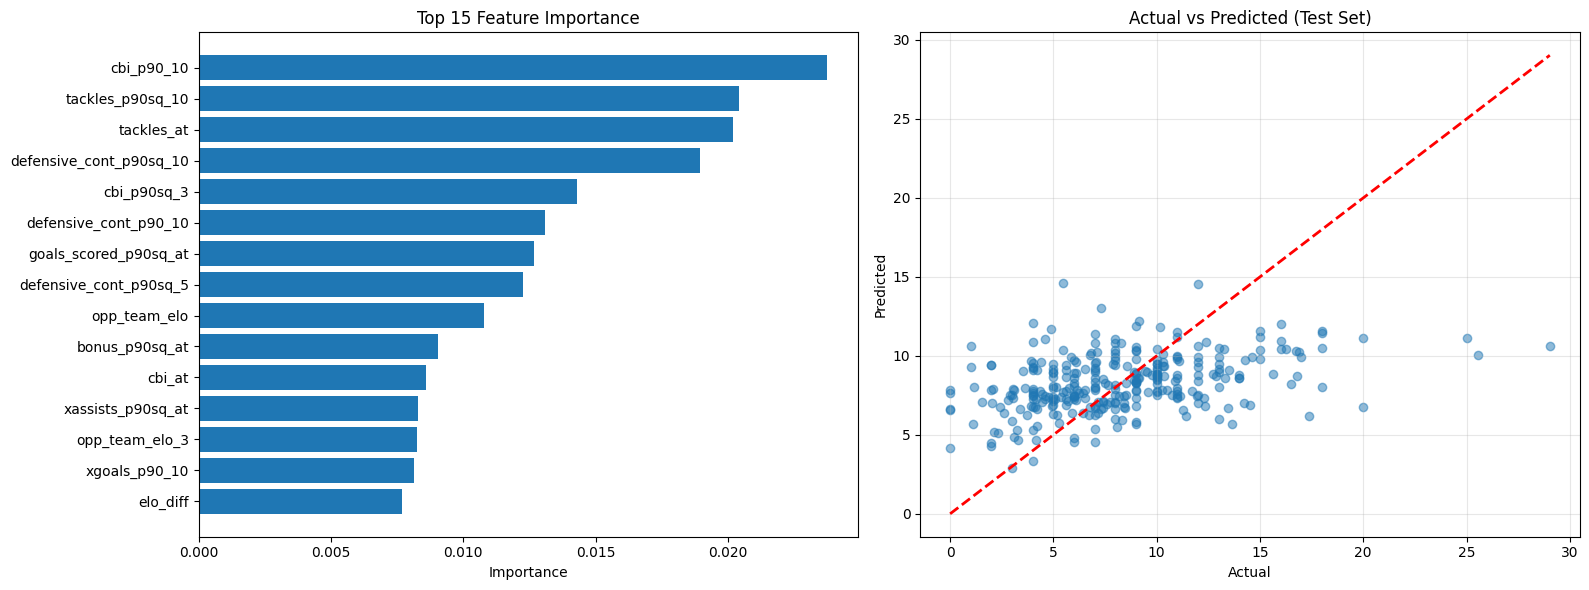

target=defensive_contribution_per90, DEF_defcon_predictor
Cleaned df size: 1295/16755

Training Set Performance:
R² Score: 0.7799
RMSE: 1.8789
MAE: 1.5184

Test Set Performance:
R² Score: -0.0582
RMSE: 3.5158
MAE: 2.7834

Top 20 Feature Importances:
                                   feature  importance
                               cbi_p90sq_3    0.031498
                                    cbi_10    0.023309
xgoal_involvements_x_defensive_cont_p90_at    0.016354
                                     cbi_5    0.015122
                                    cbi_at    0.014886
                              cbi_p90sq_10    0.014690
                              opp_team_elo    0.013273
                                  elo_diff    0.012972
                           opp_team_elo_10    0.012778
                       xassists_elo_p90_10    0.010587
                            opp_team_elo_3    0.010548
                             minutes_elo_5    0.009300
                             recove

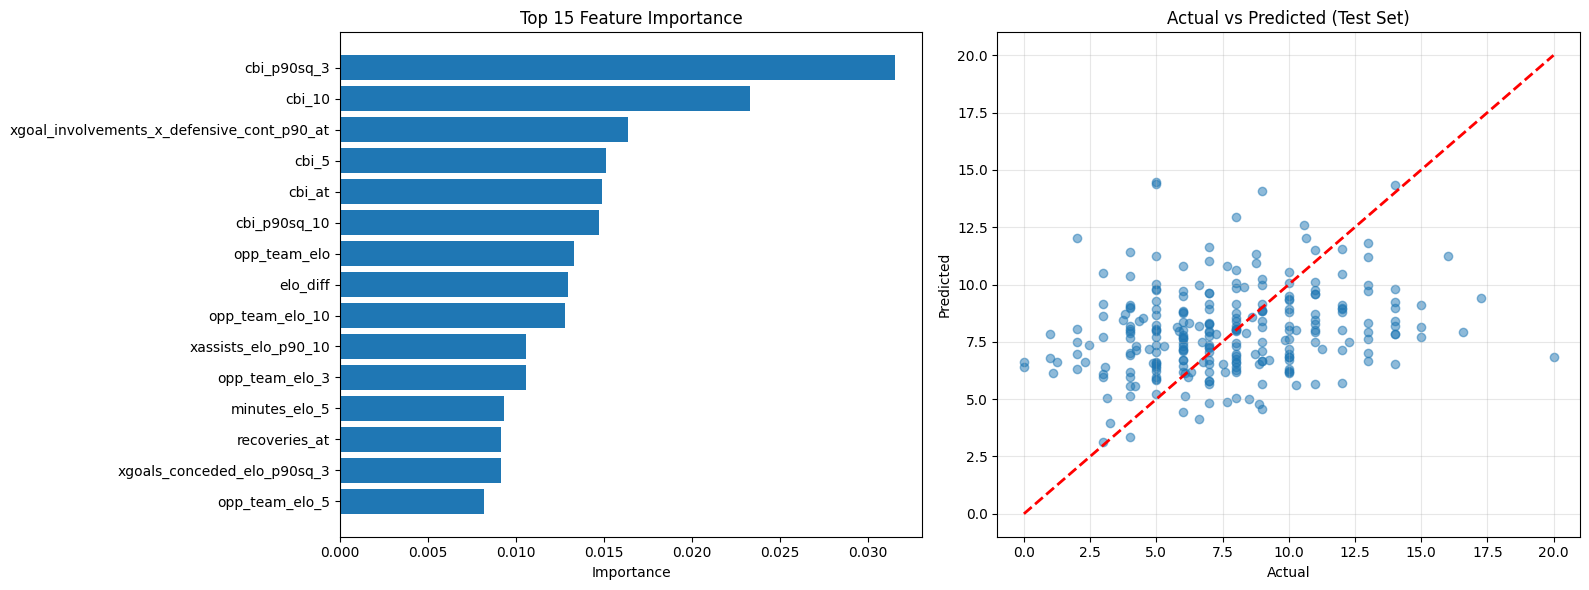

In [25]:
# >10 defcon (CBIT) for a defender
# >12 defcon (CBIT+R) for mid or fwd
filtered = (df['minutes']>30)&(df['player_season_minutes_total']>0)

if __name__ == "__main__":
    
    print("target=defensive_contribution_per90, FWD_defcon_predictor")
    FWD_defcon_predictor = FPLPredictor(
    data=df[filtered],
    target='defensive_contribution_per90',
    positions={'FWD'})
    FWD_defcon_predictor.fit()
    FWD_defcon_predictor.plot_results()

    print("target=defensive_contribution_per90, MID_defcon_predictor")
    MID_defcon_predictor = FPLPredictor(
    data=df[filtered],
    target='defensive_contribution_per90',
    positions={'MID'})
    MID_defcon_predictor.fit()
    MID_defcon_predictor.plot_results()

    print("target=defensive_contribution_per90, DEF_defcon_predictor")
    DEF_defcon_predictor = FPLPredictor(
    data=df[filtered],
    target='defensive_contribution_per90',
    positions={'DEF'})
    DEF_defcon_predictor.fit()
    DEF_defcon_predictor.plot_results()

Goals conceded per 90
Estimated λ (mean goals per match): 1.345


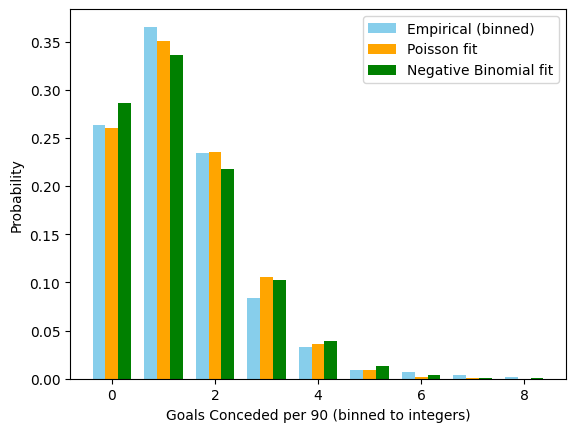

Mean: 1.337, Variance: 1.522
Overdispersion ratio (Var/Mean): 1.138
✅ Poisson assumption looks reasonable.
P(X < 1 goal) = 0.261


In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
print("Goals conceded per 90")

# Compute xGC per 90
df['xgc_p90'] = (df['expected_goals_conceded'] / df['minutes']) * 90

# Filter to reasonable samples
data = df[(df['minutes'] > 0) & (df['xgc_p90'] < 8)]['xgc_p90']

# Estimate λ
lambda_hat = np.mean(data)
print(f"Estimated λ (mean goals per match): {lambda_hat:.3f}")

# --- BINNING into discrete Poisson-like counts ---
binned = np.round(data).astype(int)
binned = np.clip(binned, 0, None)

# Empirical frequencies
values, counts = np.unique(binned, return_counts=True)
prob_empirical = counts / counts.sum()

# --- Poisson PMF ---
poisson_pmf = poisson.pmf(values, mu=lambda_hat)

# --- Negative Binomial PMF (method of moments) ---
mean_val = np.mean(binned)
var_val = np.var(binned, ddof=1)

if var_val > mean_val:
    r = (mean_val ** 2) / (var_val - mean_val)
    p = r / (r + mean_val)
    negbin_pmf = nbinom.pmf(values, n=r, p=p)
else:
    negbin_pmf = np.zeros_like(values)
    print("Variance ≤ Mean → NB undefined, skipping NB plot.")

# --- Plot ---
plt.bar(values - 0.25, prob_empirical, width=0.25, label='Empirical (binned)', color='skyblue')
plt.bar(values, poisson_pmf, width=0.25, label='Poisson fit', color='orange')
plt.bar(values + 0.25, negbin_pmf, width=0.25, label='Negative Binomial fit', color='green')
plt.xlabel('Goals Conceded per 90 (binned to integers)')
plt.ylabel('Probability')
plt.legend()
plt.show()

# --- Dispersion diagnostics ---
overdispersion_ratio = var_val / mean_val
print(f"Mean: {mean_val:.3f}, Variance: {var_val:.3f}")
print(f"Overdispersion ratio (Var/Mean): {overdispersion_ratio:.3f}")

if overdispersion_ratio > 1.2:
    print("⚠️ Likely overdispersed → Negative Binomial may fit better.")
else:
    print("✅ Poisson assumption looks reasonable.")

# --- Example probability ---
p_less_than_1 = poisson.cdf(0, mu=lambda_hat)
print(f"P(X < 1 goal) = {p_less_than_1:.3f}")


Mids & Forwards
Estimated λ (mean defcon per 90): 8.322


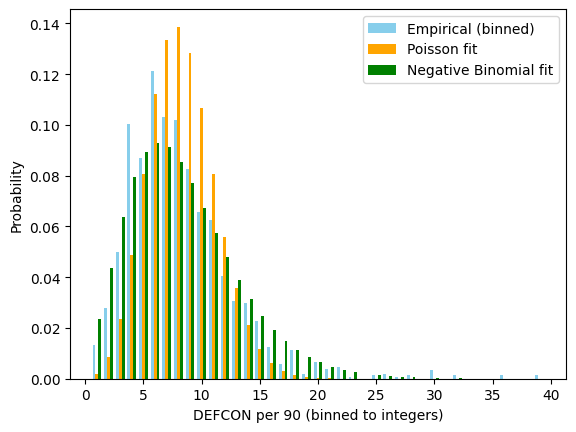

Mean: 8.315, Variance: 22.175
Overdispersion ratio (Var/Mean): 2.667
⚠️ Likely overdispersed → Negative Binomial may fit better.


In [27]:
#Test if defcon_p90 is neg binom distributed

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
print("Mids & Forwards")

# Filter to reasonable samples
data = df[(df['minutes'] > 0)
          & (df['defensive_contribution_per90'] > 0) 
          & (df['defensive_contribution_per90'] < 40)
          & (df['position'].isin(['DEF']))]['defensive_contribution_per90']

# Estimate λ
lambda_hat = np.mean(data)
print(f"Estimated λ (mean defcon per 90): {lambda_hat:.3f}")

# --- BINNING into discrete Poisson-like counts ---
binned = np.round(data).astype(int)
binned = np.clip(binned, 0, None)

# Empirical frequencies
values, counts = np.unique(binned, return_counts=True)
prob_empirical = counts / counts.sum()

# --- Poisson PMF ---
poisson_pmf = poisson.pmf(values, mu=lambda_hat)

# --- Negative Binomial PMF (method of moments) ---
mean_val = np.mean(binned)
var_val = np.var(binned, ddof=1)

if var_val > mean_val:
    r = (mean_val ** 2) / (var_val - mean_val)
    p = r / (r + mean_val)
    negbin_pmf = nbinom.pmf(values, n=r, p=p)
else:
    negbin_pmf = np.zeros_like(values)
    print("Variance ≤ Mean → NB undefined, skipping NB plot.")

# --- Plot ---
plt.bar(values - 0.25, prob_empirical, width=0.25, label='Empirical (binned)', color='skyblue')
plt.bar(values, poisson_pmf, width=0.25, label='Poisson fit', color='orange')
plt.bar(values + 0.25, negbin_pmf, width=0.25, label='Negative Binomial fit', color='green')
plt.xlabel('DEFCON per 90 (binned to integers)')
plt.ylabel('Probability')
plt.legend()
plt.show()

# --- Dispersion diagnostics ---
overdispersion_ratio = var_val / mean_val
print(f"Mean: {mean_val:.3f}, Variance: {var_val:.3f}")
print(f"Overdispersion ratio (Var/Mean): {overdispersion_ratio:.3f}")

if overdispersion_ratio > 1.2:
    print("⚠️ Likely overdispersed → Negative Binomial may fit better.")
else:
    print("✅ Poisson assumption looks reasonable.")


GK saves per 90
Estimated λ (mean defcon per 90): 3.210


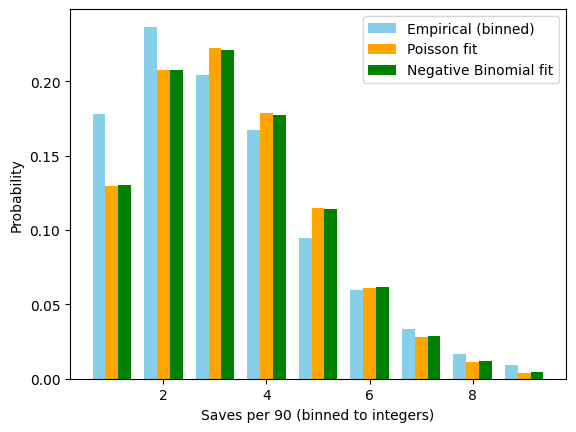

Mean: 3.210, Variance: 3.255
Overdispersion ratio (Var/Mean): 1.014
✅ Poisson assumption looks reasonable.


In [28]:
#Test if saves_p90 is neg binom distributed

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
print("GK saves per 90")

# Filter to reasonable samples
data = df[#(df['minutes'] > 0)
          (df['saves_per90'] > 0) 
          & (df['saves_per90'] < 10)
          & (df['position'].isin(['GK']))]['saves_per90']

# Estimate λ
lambda_hat = np.mean(data)
print(f"Estimated λ (mean defcon per 90): {lambda_hat:.3f}")

# --- BINNING into discrete Poisson-like counts ---
binned = np.round(data).astype(int)
binned = np.clip(binned, 0, None)

# Empirical frequencies
values, counts = np.unique(binned, return_counts=True)
prob_empirical = counts / counts.sum()

# --- Poisson PMF ---
poisson_pmf = poisson.pmf(values, mu=lambda_hat)

# --- Negative Binomial PMF (method of moments) ---
mean_val = np.mean(binned)
var_val = np.var(binned, ddof=1)

if var_val > mean_val:
    r = (mean_val ** 2) / (var_val - mean_val)
    p = r / (r + mean_val)
    negbin_pmf = nbinom.pmf(values, n=r, p=p)
else:
    negbin_pmf = np.zeros_like(values)
    print("Variance ≤ Mean → NB undefined, skipping NB plot.")

# --- Plot ---
plt.bar(values - 0.25, prob_empirical, width=0.25, label='Empirical (binned)', color='skyblue')
plt.bar(values, poisson_pmf, width=0.25, label='Poisson fit', color='orange')
plt.bar(values + 0.25, negbin_pmf, width=0.25, label='Negative Binomial fit', color='green')
plt.xlabel('Saves per 90 (binned to integers)')
plt.ylabel('Probability')
plt.legend()
plt.show()

# --- Dispersion diagnostics ---
overdispersion_ratio = var_val / mean_val
print(f"Mean: {mean_val:.3f}, Variance: {var_val:.3f}")
print(f"Overdispersion ratio (Var/Mean): {overdispersion_ratio:.3f}")

if overdispersion_ratio > 1.2:
    print("⚠️ Likely overdispersed → Negative Binomial may fit better.")
else:
    print("✅ Poisson assumption looks reasonable.")


                                 OLS Regression Results                                
Dep. Variable:                  bonus   R-squared (uncentered):                   0.447
Model:                            OLS   Adj. R-squared (uncentered):              0.447
Method:                 Least Squares   F-statistic:                          3.274e+04
Date:                Thu, 18 Dec 2025   Prob (F-statistic):                        0.00
Time:                        14:47:55   Log-Likelihood:                         -38097.
No. Observations:               40432   AIC:                                  7.620e+04
Df Residuals:                   40431   BIC:                                  7.621e+04
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

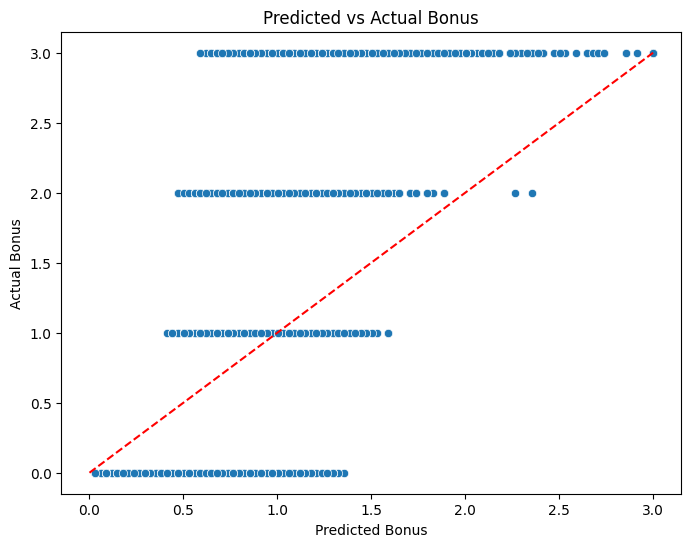

C:\Users\Chris\AppData\Local\Temp\ipykernel_9108\2893669323.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rmse_table = df.groupby(['position', 'bonus']).apply(lambda x: rmse(x['bonus'], x['bonus_pred']))


Actual Bonus       0.0       1.0       2.0       3.0
Position                                            
DEF           0.459184  0.231393  1.106750  1.949415
FWD           0.332109  0.199669  1.047797  1.710401
GK            0.491502  0.246331  1.116638  2.014220
GKP                NaN       NaN       NaN       NaN
MID           0.395054  0.246063  1.050797  1.823660


In [30]:
# Generalize the relationship between bps & bonus points
import statsmodels.formula.api as smf
filtered = (df['minutes']>45) & (df['bonus']>=0) & (df['bps']>0) & (df['position'].isin(['GK','DEF','MID','FWD']))
# df['bonus_sq'] = df['bonus']**2

model = smf.ols('bonus ~ bps -1', data=df[filtered]).fit()
print(model.summary())

df['bonus_pred'] = model.predict(df[filtered])
df['bonus_pred'] = np.clip(df['bonus_pred'], 0, 3) # clip prediction to 3

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(x='bonus_pred', y='bonus', data=df)
plt.plot([df['bonus'].min(), df['bonus'].max()],
         [df['bonus'].min(), df['bonus'].max()],
         color='red', linestyle='--')  # 45-degree line
plt.xlabel('Predicted Bonus')
plt.ylabel('Actual Bonus')
plt.title('Predicted vs Actual Bonus')
plt.show()

import pandas as pd
import numpy as np

# Function to calculate RMSE
def rmse(actual, predicted):
    return np.sqrt(np.mean((actual - predicted) ** 2))

# Group by position and actual bonus, then calculate RMSE
rmse_table = df.groupby(['position', 'bonus']).apply(lambda x: rmse(x['bonus'], x['bonus_pred']))

# Convert to DataFrame
rmse_table = rmse_table.reset_index()
rmse_table.columns = ['Position', 'Actual Bonus', 'RMSE']

pivot_rmse = rmse_table.pivot(index='Position', columns='Actual Bonus', values='RMSE')
print(pivot_rmse)


In [31]:
prediction_data = df[(df['season']==20252026)
                     &(df['event']>=stats_current_gameweek+1)]

In [32]:
prediction_data.pivot_table(index='event',values='minutes',aggfunc='count')

,minutes
event,
17.0,0
18.0,0
19.0,0
20.0,0
21.0,0
22.0,0
23.0,0
24.0,0
25.0,0


In [33]:
def predict_target_vectorized(df, model_dict, col_name):
    preds = []
    
    for pos, model in model_dict.items():
        subset = df[df['position'] == pos]
        if not subset.empty:
            pos_preds = model.predict_new(subset)
            temp = subset.copy()
            temp[col_name] = pos_preds
            preds.append(temp)
    
    if not preds:
        # If no positions matched at all
        return pd.Series(index=df.index, dtype=float)
    
    result = pd.concat(preds)
    
    # Safely align back to original DataFrame
    output = pd.Series(index=df.index, dtype=float)
    output.loc[result.index] = result[col_name]
    return output

In [34]:
target_col_name = 'mins_pred'
mins_model_dict = {'FWD': FWD_mins_predictor, 'MID': MID_mins_predictor, 'DEF': DEF_mins_predictor, 'GK': GK_mins_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, mins_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_9108\2521843321.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, mins_model_dict, col_name=target_col_name)


count    10230.000000
mean        42.972906
std         29.216641
min          0.797210
25%         14.666279
50%         40.801918
75%         71.053021
max         90.000000
Name: mins_pred, dtype: float64

In [35]:
target_col_name = 'xgp90_pred'
xg_model_dict = {'FWD': FWD_xG_predictor, 'MID': MID_xG_predictor, 'DEF': DEF_xG_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xg_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_9108\365369552.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xg_model_dict, col_name=target_col_name)


count    9570.000000
mean        0.197264
std         0.155839
min         0.017897
25%         0.059927
50%         0.158849
75%         0.302600
max         0.690313
Name: xgp90_pred, dtype: float64

In [36]:
target_col_name = 'xap90_pred'
xA_model_dict = {'FWD': FWD_xA_predictor, 'MID': MID_xA_predictor, 'DEF': DEF_xA_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xA_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_9108\4144355699.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xA_model_dict, col_name=target_col_name)


count    9570.000000
mean        0.111248
std         0.074385
min         0.010873
25%         0.050744
50%         0.099045
75%         0.160569
max         0.378684
Name: xap90_pred, dtype: float64

In [37]:
target_col_name = 'xgcp90_pred'
xGC_model_dict = {'FWD': FWD_xGC_predictor, 'MID': MID_xGC_predictor, 'DEF': DEF_xGC_predictor, 'GK':GK_xGC_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xGC_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_9108\682035545.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xGC_model_dict, col_name=target_col_name)


count    10230.000000
mean         1.385566
std          0.346453
min          0.504878
25%          1.130986
50%          1.319420
75%          1.622430
max          2.654433
Name: xgcp90_pred, dtype: float64

In [38]:
target_col_name = 'xbpsp90_pred'
bps_model_dict = {'FWD': FWD_bps_predictor, 'MID': MID_bps_predictor, 'DEF': DEF_bps_predictor, 'GK':GK_bps_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, bps_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_9108\3051138591.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, bps_model_dict, col_name=target_col_name)


count    10230.000000
mean        17.589393
std          6.317768
min          0.800328
25%         13.876644
50%         16.934484
75%         20.310859
max         47.915042
Name: xbpsp90_pred, dtype: float64

In [39]:
target_col_name = 'xsavesp90_pred'
saves_model_dict = {'GK':GK_saves_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, saves_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_9108\803536942.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, saves_model_dict, col_name=target_col_name)


count    660.000000
mean       2.794089
std        0.580444
min        1.463027
25%        2.471770
50%        2.789128
75%        3.130836
max        4.332475
Name: xsavesp90_pred, dtype: float64

In [40]:
target_col_name = 'xdefconp90_pred'
defcon_model_dict = {'FWD': FWD_defcon_predictor, 'MID': MID_defcon_predictor, 'DEF': DEF_defcon_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, defcon_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_9108\2777375241.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, defcon_model_dict, col_name=target_col_name)


count    9570.000000
mean        7.790955
std         2.026720
min         2.195364
25%         6.492014
50%         7.942669
75%         9.098599
max        14.716420
Name: xdefconp90_pred, dtype: float64

In [41]:
prediction_data[prediction_data['position']=='MID'].head()[["player_name_id","element","value","team_name","position","season","event","opp_team_name","opp_team_elo"
    ,'mins_pred','xgp90_pred','xap90_pred','xgcp90_pred'
    ]]

,player_name_id,element,value,team_name,position,season,event,opp_team_name,opp_team_elo,mins_pred,xgp90_pred,xap90_pred,xgcp90_pred
129053,Ben Winterburn,96.0,45.0,Bournemouth,MID,20252026.0,17.0,Burnley,874.844690,2.234948,0.372645,0.269183,1.258849
129114,Ben Winterburn,96.0,45.0,Bournemouth,MID,20252026.0,18.0,Brentford,1043.259019,1.358080,0.358122,0.168528,1.142416
129127,Ben Winterburn,96.0,45.0,Bournemouth,MID,20252026.0,19.0,Chelsea,1137.749717,1.368841,0.343092,0.152256,1.524102
129150,Ben Winterburn,96.0,45.0,Bournemouth,MID,20252026.0,20.0,Arsenal,1240.846578,1.368841,0.349866,0.149728,1.591662
129159,Ben Winterburn,96.0,45.0,Bournemouth,MID,20252026.0,21.0,Spurs,1004.948752,1.358080,0.358122,0.174178,1.184758


In [42]:
prediction_data[
    (prediction_data['event']==picks_current_gameweek+1)
    &(prediction_data['mins_pred']>0)
    ][["player_name_id","element","value","team_name","position","season","event","opp_team_name","opp_team_elo"
    ,'mins_pred','xgp90_pred','xap90_pred','xgcp90_pred'
    ]].sort_values(by='xgp90_pred',ascending=False
        ).head(10)

,player_name_id,element,value,team_name,position,season,event,opp_team_name,opp_team_elo,mins_pred,xgp90_pred,xap90_pred,xgcp90_pred
146473,Viktor Gyökeres,666.0,88.0,Arsenal,FWD,20252026.0,17.0,Everton,1065.587055,46.239114,0.685818,0.044344,1.202041
134528,Erling Haaland,430.0,150.0,Man City,FWD,20252026.0,17.0,West Ham,976.747412,79.019333,0.685476,0.108749,1.243344
138910,Kai Havertz,30.0,73.0,Arsenal,FWD,20252026.0,17.0,Everton,1065.587055,1.270447,0.633022,0.204255,1.466551
145434,Stefanos Tzimas,180.0,53.0,Brighton,FWD,20252026.0,17.0,Sunderland,1052.664829,8.248091,0.630482,0.091457,1.444174
142784,Odsonne Édouard,285.0,50.0,Crystal Palace,FWD,20252026.0,17.0,Leeds,940.296844,0.849708,0.591773,0.199439,1.341953
146728,William Osula,500.0,54.0,Newcastle,FWD,20252026.0,17.0,Chelsea,1137.749717,8.317017,0.590339,0.166526,1.707022
145613,Taiwo Awoniyi,527.0,52.0,Nott'm Forest,FWD,20252026.0,17.0,Fulham,1029.261205,5.242840,0.583192,0.157516,1.226076
130259,Alexander Isak,499.0,104.0,Liverpool,FWD,20252026.0,17.0,Spurs,1004.948752,31.025163,0.580720,0.054953,1.366522
146916,Yoane Wissa,135.0,73.0,Newcastle,FWD,20252026.0,17.0,Chelsea,1137.749717,20.284044,0.576242,0.126975,1.684550
134114,Eddie Nketiah,284.0,54.0,Crystal Palace,FWD,20252026.0,17.0,Leeds,940.296844,47.740548,0.572417,0.061712,1.268511


In [43]:
import pandas as pd
from scipy.stats import nbinom

def calculate_negbinom_parameters(position_list, df):

    # 1. Calculate mean and variance
    filtered = (df['minutes'] > 0) & (df['defensive_contribution_per90'] > 0) & (df['defensive_contribution_per90'] < 40) & (df['position'].isin(position_list))
    mean = df[filtered]['defensive_contribution_per90'].mean()
    variance = df[filtered]['defensive_contribution_per90'].var()
    # r = number of successes
    r = (mean**2) / (variance - mean)
    # p = success probability
    p = r / (r + mean)
    return r,p

In [44]:
from scipy.stats import poisson
import numpy as np

def expected_score(mu, max_events=10, rule=None, points_per_n=None, points_value=None):
    """
    Calculate the expected score given an average event rate (mu)
    using a Poisson model.

    Parameters
    ----------
    mu : float
        Expected number of events (e.g., goals conceded, shots saved).
    max_events : int
        Maximum number of discrete events to sum over.
    rule : callable, optional
        Function that maps event count -> points. Example: lambda k: -np.floor(k / 2)
    points_per_n : int, optional
        For simple rules: number of events required for one point (e.g. 3 shots saved = 1 pt)
    points_value : float, optional
        Value of that one point (e.g. +1 for shots saved, -1 for goals conceded)

    Returns
    -------
    float
        Expected points based on Poisson-distributed event counts.
    """
    array = np.arange(0, max_events + 1)
    probs = poisson.pmf(array, mu)

    if rule is not None:
        scores = np.array([rule(k) for k in array])
    elif points_per_n is not None and points_value is not None:
        # General simple rule: 1 point_value for every n events
        scores = np.floor(array / points_per_n) * points_value
    else:
        raise ValueError("You must provide either a rule function or both points_per_n and points_value.")

    return np.sum(scores * probs)


In [45]:
scoring_dict = {
    "FWD": {'xgp90_pred': 4, 'xap90_pred': 3, 'xgcp90_pred': 0, 'xgc_ss':0, 'defcon':2},
    "MID": {'xgp90_pred': 5, 'xap90_pred': 3, 'xgcp90_pred': 1, 'xgc_ss':0, 'defcon':2},
    "DEF": {'xgp90_pred': 6, 'xap90_pred': 3, 'xgcp90_pred': 4, 'xgc_ss':-1, 'defcon':2},
    "GK":  {'xgp90_pred': 10, 'xap90_pred': 3, 'xgcp90_pred': 4, 'xgc_ss':-1, 'defcon':2}
}

def scoring(x, scoring_dict, points_type, negbinom_rp_dict=None):
    mins_factor = x['mins_pred']/90
    if points_type == 'mins':
        if pd.isna(x['mins_pred']):
            return 0
        elif x['mins_pred'] >= 60:
            return 2
        elif x['mins_pred'] > 0:
            return 1
        else:
            return 0
    if points_type == 'goals':
        goals_points = mins_factor * x['xgp90_pred'] * scoring_dict[x['position']]['xgp90_pred']
        return goals_points
    if points_type == 'assists':
        assist_points = mins_factor * x['xap90_pred'] * scoring_dict[x['position']]['xap90_pred']
        return assist_points
    if points_type == 'clean_sheets':
        p_less_than_1 = poisson.cdf(0, mu=x['xgcp90_pred'])
        cs_points = p_less_than_1 * scoring_dict[x['position']]['xgcp90_pred']
        return cs_points
    
    if points_type == 'shots_saved': 
        if x['position'] == 'GK':
            saves_points = expected_score(mu=x['xsavesp90_pred'],  # expected shots saved per 90
                                   max_events=15,
                                   points_per_n=3, #for every 3 shots saved
                                   points_value=1) #scores 1 point
            return saves_points
        else:
            return 0
        
    if points_type == 'goals_conceded':
        if x['position'] in ['DEF','GK']:
            gc_points = expected_score(mu=x['xgcp90_pred'], 
                                   max_events=10, 
                                   points_per_n=2, #for every 2 goals conceded 
                                   points_value=-1) #scores -1 points 
            return gc_points
        else:
            return 0

    if points_type == 'defcon':
        pos = x['position']
        if pos in ['MID','FWD']:
            r = negbinom_rp_dict[pos]['r']
            p = negbinom_rp_dict[pos]['p']
            k = 12
            prob_more_than_12 = 1 - nbinom.cdf(k, r, p)
            defcon_points = prob_more_than_12 * scoring_dict[pos]['defcon']
            return defcon_points
        elif pos == 'DEF':
            r = negbinom_rp_dict[pos]['r']
            p = negbinom_rp_dict[pos]['p']
            k = 10
            prob_more_than_12 = 1 - nbinom.cdf(k, r, p)
            defcon_points = prob_more_than_12 * scoring_dict[pos]['defcon']
            return defcon_points
        else: return 0

    if points_type == 'bonus':
        return x['xbpsp90_pred']*0.0294 # ols regression coefficient

prediction_data['xpoints_mins'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='mins'), axis=1)
prediction_data['xpoints_goals'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='goals'), axis=1)
prediction_data['xpoints_assists'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='assists'), axis=1)
prediction_data['xpoints_clean_sheets'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='clean_sheets'), axis=1)

prediction_data['xpoints_shots_saved'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='shots_saved'), axis=1)
prediction_data['xpoints_goals_conceded'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='goals_conceded'), axis=1)

def_r,def_p = calculate_negbinom_parameters(['DEF'], df)
mid_r,mid_p = calculate_negbinom_parameters(['MID'], df)
fwd_r,fwd_p = calculate_negbinom_parameters(['FWD'], df)
rp_dict = {'DEF':{'r':def_r,'p':def_p},'MID':{'r':mid_r,'p':mid_p},'FWD':{'r':fwd_r,'p':fwd_p}}
prediction_data['xpoints_defcon'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='defcon', negbinom_rp_dict=rp_dict), axis=1)
prediction_data['xpoints_bonus'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='bonus'), axis=1)

prediction_data['xpoints'] = prediction_data[['xpoints_mins', 'xpoints_goals', 'xpoints_assists', 'xpoints_clean_sheets',
                                              'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus']].sum(axis=1, skipna=True)

C:\Users\Chris\AppData\Local\Temp\ipykernel_9108\282654768.py:71: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['xpoints_mins'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='mins'), axis=1)
C:\Users\Chris\AppData\Local\Temp\ipykernel_9108\282654768.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['xpoints_goals'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='goals'), axis=1)
C:\Users\Chris\AppData\Local\Temp\ipykernel_91

In [46]:
predictions = prediction_data[['player_name_id', 'team_name','team_elo','element','position','opp_team_name','opp_team_elo', 'season', 'value', 'event',
                       'mins_pred', 'xgp90_pred', 'xap90_pred', 'xgcp90_pred',
                       'xpoints_mins', 'xpoints_goals', 'xpoints_assists', 'xpoints_clean_sheets','xpoints_shots_saved',
                       'xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
                       'xpoints']]
predictions

,player_name_id,team_name,team_elo,element,position,opp_team_name,opp_team_elo,season,value,event,...,xgcp90_pred,xpoints_mins,xpoints_goals,xpoints_assists,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus,xpoints
127426,Bashir Humphreys,Burnley,874.844690,193.0,DEF,Chelsea,1137.749717,20252026.0,39.0,27.0,...,1.905035,1,0.015869,0.003414,0.595270,0.0,-0.708027,0.558424,0.282145,1.747095
127613,Bashir Humphreys,Burnley,874.844690,193.0,DEF,Brentford,1043.259019,20252026.0,39.0,28.0,...,2.157294,1,0.017039,0.003601,0.462550,0.0,-0.831904,0.558424,0.303064,1.512774
127935,Bashir Humphreys,Burnley,874.844690,193.0,DEF,Everton,1065.587055,20252026.0,39.0,29.0,...,2.226629,1,0.017145,0.003601,0.431566,0.0,-0.866110,0.558424,0.284874,1.429500
128286,Bashir Humphreys,Burnley,874.844690,193.0,DEF,Bournemouth,1047.663673,20252026.0,39.0,30.0,...,2.157294,1,0.017039,0.003601,0.462550,0.0,-0.831904,0.558424,0.303064,1.512774
128289,Bashir Humphreys,Burnley,874.844690,193.0,DEF,Fulham,1029.261205,20252026.0,39.0,31.0,...,2.157294,1,0.017039,0.003601,0.462550,0.0,-0.831904,0.558424,0.303064,1.512774
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147327,Álex Jiménez Sánchez,Bournemouth,1047.663673,713.0,DEF,Leeds,940.296844,20252026.0,45.0,34.0,...,1.245344,2,0.127842,0.154160,1.151367,0.0,-0.393385,0.558424,0.405022,4.003431
147328,Álex Jiménez Sánchez,Bournemouth,1047.663673,713.0,DEF,Crystal Palace,1100.427069,20252026.0,45.0,35.0,...,1.721583,2,0.114887,0.155330,0.715132,0.0,-0.618772,0.558424,0.259650,3.184652
147329,Álex Jiménez Sánchez,Bournemouth,1047.663673,713.0,DEF,Fulham,1029.261205,20252026.0,45.0,36.0,...,1.297914,2,0.122646,0.155330,1.092403,0.0,-0.417602,0.558424,0.320753,3.831955
147330,Álex Jiménez Sánchez,Bournemouth,1047.663673,713.0,DEF,Man City,1236.029561,20252026.0,45.0,37.0,...,1.884343,2,0.113895,0.155676,0.607715,0.0,-0.697917,0.558424,0.222550,2.960344


In [47]:
prediction_data[
    (prediction_data['event']==picks_current_gameweek+1)
    &(prediction_data['mins_pred']>60)
    #&(prediction_data['position'].isin(['MID','FWD']))
    ][["player_name_id","element","value","team_name","position","event","opp_team_name","opp_team_elo"
    ,'mins_pred','xgp90_pred','xap90_pred','xdefconp90_pred','xbpsp90_pred','xpoints'
    ]].sort_values(by='xpoints',ascending=False
        ).head(10)

,player_name_id,element,value,team_name,position,event,opp_team_name,opp_team_elo,mins_pred,xgp90_pred,xap90_pred,xdefconp90_pred,xbpsp90_pred,xpoints
143903,Phil Foden,414.0,87.0,Man City,MID,17.0,West Ham,976.747412,74.840659,0.491076,0.270464,7.655021,37.736902,6.760431
131896,Bruno Borges Fernandes,449.0,92.0,Man Utd,MID,17.0,Aston Villa,1173.335624,69.838360,0.453145,0.322115,11.250732,33.857952,6.092706
142819,Nico O'Reilly,411.0,52.0,Man City,DEF,17.0,West Ham,976.747412,85.188666,0.147540,0.114747,7.068084,22.946021,6.039245
134528,Erling Haaland,430.0,150.0,Man City,FWD,17.0,West Ham,976.747412,79.019333,0.685476,0.108749,4.505196,32.978471,5.932372
130010,Adrien Truffert,74.0,45.0,Bournemouth,DEF,17.0,Burnley,874.844690,86.135913,0.227550,0.112819,7.527527,17.513938,5.686056
142332,Morgan Gibbs-White,515.0,73.0,Nott'm Forest,MID,17.0,Fulham,1029.261205,81.786614,0.393331,0.108727,5.751917,17.043637,5.542716
131137,Bafodé Diakité,685.0,44.0,Bournemouth,DEF,17.0,Burnley,874.844690,82.907206,0.257659,0.042147,7.229681,14.251103,5.455927
130825,Antoine Semenyo,82.0,76.0,Bournemouth,MID,17.0,Burnley,874.844690,80.939523,0.283768,0.236460,8.057467,23.538817,5.371593
138696,Joško Gvardiol,403.0,59.0,Man City,DEF,17.0,West Ham,976.747412,76.849053,0.106477,0.074891,8.104045,21.413847,5.322541
144235,Riccardo Calafiori,7.0,57.0,Arsenal,DEF,17.0,Everton,1065.587055,70.516587,0.074836,0.053204,6.585545,21.118730,5.320714


In [48]:
table_name = "predictions"
if __name__ == "__main__":
    db_creator.create_staging_table_then_insert_data(table_name, data=predictions)
    preds = db_creator.table_to_df(table_name=table_name)
    print(preds.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10230 entries, 0 to 10229
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   player_name_id          10230 non-null  object 
 1   team_name               10230 non-null  object 
 2   team_elo                10230 non-null  float64
 3   element                 10230 non-null  float64
 4   position                10230 non-null  object 
 5   opp_team_name           10230 non-null  object 
 6   opp_team_elo            10230 non-null  float64
 7   season                  10230 non-null  float64
 8   value                   10230 non-null  float64
 9   event                   10230 non-null  float64
 10  mins_pred               10230 non-null  float64
 11  xgp90_pred              9570 non-null   float64
 12  xap90_pred              9570 non-null   float64
 13  xgcp90_pred             10230 non-null  float64
 14  xpoints_mins            10230 non-null

In [49]:
# Add new columns to the xPoints table
db_creator.execute_sql("""
    ALTER TABLE predictions
    ADD COLUMN IF NOT EXISTS in_any_team INTEGER DEFAULT 0,
    ADD COLUMN IF NOT EXISTS in_my_team INTEGER DEFAULT 0
""")

In [50]:
current_gameweek = picks_current_gameweek
my_name = "Christopher Harris"

# Get the player lists
view = db_creator.run_sql(f"""
    WITH 
    current_players AS (
        SELECT element
        FROM fpl_picks
        WHERE gw = {current_gameweek}
    ),
    my_players AS (
        SELECT element
        FROM fpl_picks
        WHERE gw = {current_gameweek}
        AND member = '{my_name}'
    )
    SELECT * FROM my_players
""")

# Update the flags
db_creator.execute_sql(f"""
    UPDATE predictions
    SET in_any_team = 1
    WHERE element IN (
        SELECT element 
        FROM fpl_picks 
        WHERE gw = {current_gameweek}
    )
""")

db_creator.execute_sql(f"""
    UPDATE predictions
    SET in_my_team = 1
    WHERE element IN (
        SELECT element 
        FROM fpl_picks 
        WHERE gw = {current_gameweek}
        AND member = '{my_name}'
    )
""")

In [51]:
print(f"Gameweek {picks_current_gameweek+1} Predictions")
prediction_data[
    prediction_data['event']==picks_current_gameweek+1
][["player_name_id","element",'event',"value","team_name","position","opp_team_name","opp_team_elo"
   ,'mins_pred', 'xpoints_mins', 'xpoints_goals', 'xpoints_assists', 'xpoints_clean_sheets', 
   'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
   'xpoints'
   ]].sort_values(by='xpoints',ascending=False
    ).head(10)

Gameweek 17 Predictions


,player_name_id,element,event,value,team_name,position,opp_team_name,opp_team_elo,mins_pred,xpoints_mins,xpoints_goals,xpoints_assists,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus,xpoints
143903,Phil Foden,414.0,17.0,87.0,Man City,MID,West Ham,976.747412,74.840659,2,2.041804,0.674723,0.435762,0.0,0.000000,0.498677,1.109465,6.760431
131896,Bruno Borges Fernandes,449.0,17.0,92.0,Man Utd,MID,Aston Villa,1173.335624,69.838360,2,1.758161,0.749865,0.090580,0.0,0.000000,0.498677,0.995424,6.092706
142819,Nico O'Reilly,411.0,17.0,52.0,Man City,DEF,West Ham,976.747412,85.188666,2,0.837918,0.325839,1.834744,0.0,-0.192293,0.558424,0.674613,6.039245
134528,Erling Haaland,430.0,17.0,150.0,Man City,FWD,West Ham,976.747412,79.019333,2,2.407371,0.286443,0.000000,0.0,0.000000,0.268991,0.969567,5.932372
130010,Adrien Truffert,74.0,17.0,45.0,Bournemouth,DEF,Burnley,874.844690,86.135913,2,1.306681,0.323925,1.315272,0.0,-0.333156,0.558424,0.514910,5.686056
142332,Morgan Gibbs-White,515.0,17.0,73.0,Nott'm Forest,MID,Fulham,1029.261205,81.786614,2,1.787180,0.296414,0.459362,0.0,0.000000,0.498677,0.501083,5.542716
131137,Bafodé Diakité,685.0,17.0,44.0,Bournemouth,DEF,Burnley,874.844690,82.907206,2,1.424121,0.116477,1.282400,0.0,-0.344477,0.558424,0.418982,5.455927
130825,Antoine Semenyo,82.0,17.0,76.0,Bournemouth,MID,Burnley,874.844690,80.939523,2,1.276001,0.637966,0.266908,0.0,0.000000,0.498677,0.692041,5.371593
138696,Joško Gvardiol,403.0,17.0,59.0,Man City,DEF,West Ham,976.747412,76.849053,2,0.545512,0.191844,1.636026,0.0,-0.238834,0.558424,0.629567,5.322541
144235,Riccardo Calafiori,7.0,17.0,57.0,Arsenal,DEF,Everton,1065.587055,70.516587,2,0.351811,0.125059,1.852937,0.0,-0.188408,0.558424,0.620891,5.320714


In [52]:
current_gameweek=picks_current_gameweek
print(f"Next 5 GWs: GW{current_gameweek+1} - GW{current_gameweek+5}")
next_5_gws_filter = (prediction_data['event']>=current_gameweek)&(prediction_data['event']<=current_gameweek+5)
prediction_data[next_5_gws_filter].groupby('player_name_id')[['mins_pred', 'xpoints_mins', 'xpoints_goals', 
                                           'xpoints_assists', 'xpoints_clean_sheets', 'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
                                           'xpoints'
                                           ]].agg('sum').reset_index().sort_values(by='xpoints',ascending=False).head(10)

Next 5 GWs: GW17 - GW21


,player_name_id,mins_pred,xpoints_mins,xpoints_goals,xpoints_assists,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus,xpoints
55,Bruno Borges Fernandes,348.477271,10,9.739490,4.011050,0.830998,0.0,0.000000,2.493385,5.919879,32.994801
371,Phil Foden,374.203296,10,9.644023,3.234162,1.542824,0.0,0.000000,2.493385,5.058221,31.972615
16,Amad Diallo,410.241965,10,8.951686,3.048528,1.333293,0.0,0.000000,2.493385,3.704012,29.530904
121,Erling Haaland,395.756093,10,12.077194,1.128985,0.000000,0.0,0.000000,1.344954,4.891237,29.442371
57,Bryan Mbeumo,407.983200,10,7.897585,3.772504,1.230514,0.0,0.000000,2.493385,3.140828,28.534816
343,Nico O'Reilly,425.943328,10,3.730656,1.533344,7.752318,0.0,-1.325701,2.792122,3.316476,27.799215
329,Morgan Gibbs-White,407.031948,10,8.926146,1.423926,1.597116,0.0,0.000000,2.493385,2.330014,26.770587
302,Matheus Santos Carneiro da Cunha,364.061850,10,6.613521,2.359573,1.247068,0.0,0.000000,2.493385,3.531619,26.245166
163,Hugo Ekitiké,329.899271,10,7.621264,0.630677,0.000000,0.0,0.000000,1.344954,6.161042,25.757937
381,Riccardo Calafiori,353.122025,10,1.705112,0.621964,8.606937,0.0,-1.097689,2.792122,3.012989,25.641435


In [53]:
print("Rest of Season Predictions")
prediction_data.groupby('player_name_id')[['mins_pred', 'xpoints_mins', 'xpoints_goals', 
                                           'xpoints_assists', 'xpoints_clean_sheets', 
                                           'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
                                           'xpoints'
                                           ]].agg('sum').reset_index().sort_values(by='xpoints',ascending=False).head(10)

Rest of Season Predictions


,player_name_id,mins_pred,xpoints_mins,xpoints_goals,xpoints_assists,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus,xpoints
371,Phil Foden,1646.494501,44,42.503448,14.377950,6.904867,0.0,0.000000,10.970892,21.907041,140.664199
55,Bruno Borges Fernandes,1535.729393,44,40.475072,16.948317,3.390953,0.0,0.000000,10.970892,23.546864,139.332099
121,Erling Haaland,1740.352563,44,53.001279,5.092587,0.000000,0.0,0.000000,5.917799,21.479255,129.490920
343,Nico O'Reilly,1873.283476,44,17.638063,7.017343,34.260271,0.0,-5.823582,12.285337,14.390236,123.767667
16,Amad Diallo,1807.907986,44,36.992517,11.909894,5.240283,0.0,0.000000,10.970892,13.542383,122.655969
381,Riccardo Calafiori,1547.053643,44,8.773432,2.803219,43.102459,0.0,-3.853282,12.285337,13.486773,120.597938
329,Morgan Gibbs-White,1791.032012,44,39.472622,6.614975,7.013297,0.0,0.000000,10.970892,10.440652,118.512437
57,Bryan Mbeumo,1797.969422,44,31.120902,15.461709,4.888344,0.0,0.000000,10.970892,11.740610,118.182458
239,Jurriën Timber,1689.439237,44,18.632946,3.605116,34.972077,0.0,-5.745981,12.285337,8.399489,116.148984
97,Diego Gómez Amarilla,1346.346374,42,41.005589,4.257854,5.754117,0.0,0.000000,10.970892,10.363447,114.351900


In [54]:
from datetime import datetime

# Add the columns
db_creator.execute_sql("""
    ALTER TABLE predictions
    ADD COLUMN IF NOT EXISTS prediction_timestamp TIMESTAMP,
    ADD COLUMN IF NOT EXISTS prediction_gameweek INTEGER;
""")

# Update ALL existing rows with current timestamp and gameweek
db_creator.execute_sql("""
    UPDATE predictions
    SET prediction_timestamp = :timestamp,
        prediction_gameweek = :gameweek;
""", params={
    'timestamp': datetime.now(),
    'gameweek': picks_current_gameweek
})

In [ ]:
# # Reset predictions table

# db_creator.execute_sql("""
#     DROP TABLE IF EXISTS predictions_allgws
# """)

In [60]:
# Create predictions_allgws if it doesn't exist
db_creator.execute_sql("""
    CREATE TABLE IF NOT EXISTS predictions_allgws AS
    SELECT p.*,
            -- pg.player_name_id, pg.team_name, pg.team_elo, pg.element, pg.position, pg.opp_team_name, pg.opp_team_elo, pg.value,
            pg.fixture, pg.total_points, pg.minutes, pg.goals_scored, pg.assists, pg.bonus, 
            pg.bps, pg.clean_sheets, pg.goals_conceded, pg.was_home, pg.expected_assists, 
            pg.expected_goal_involvements, pg.expected_goals, pg.expected_goals_conceded, 
            pg.starts, pg.cbi, pg.defensive_contribution, pg.recoveries, pg.tackles, pg.saves 
            
    FROM predictions p
    LEFT JOIN playergw pg 
        ON p.player_name_id = pg.player_name_id 
        AND p.event = pg.event
        AND p.season = pg.season
    WHERE 1=0;  -- Empty table with correct schema
""")

In [61]:
# Step 1: Insert new predictions that don't exist yet
db_creator.execute_sql("""
INSERT INTO predictions_allgws (
    player_name_id, team_name, team_elo, element, position, opp_team_name, 
    opp_team_elo, value, event, season, xpoints, 
    prediction_timestamp, prediction_gameweek,  -- Add these explicitly
    fixture, total_points, minutes, goals_scored, assists, bonus, 
    bps, clean_sheets, goals_conceded, was_home, expected_assists, 
    expected_goal_involvements, expected_goals, expected_goals_conceded, 
    starts, cbi, defensive_contribution, recoveries, tackles, saves
)
SELECT 
    p.player_name_id, p.team_name, p.team_elo, p.element, p.position, 
    p.opp_team_name, p.opp_team_elo, p.value, p.event, p.season, 
    p.xpoints, p.prediction_timestamp, p.prediction_gameweek,  -- Include new columns
    pg.fixture, pg.total_points, pg.minutes, pg.goals_scored, pg.assists, 
    pg.bonus, pg.bps, pg.clean_sheets, pg.goals_conceded, pg.was_home, 
    pg.expected_assists, pg.expected_goal_involvements, pg.expected_goals, 
    pg.expected_goals_conceded, pg.starts, pg.cbi, pg.defensive_contribution, 
    pg.recoveries, pg.tackles, pg.saves
FROM predictions p
LEFT JOIN playergw pg 
    ON p.player_name_id = pg.player_name_id 
    AND p.event = pg.event 
    AND p.season = pg.season
WHERE NOT EXISTS (
    SELECT 1 
    FROM predictions_allgws pa 
    WHERE pa.player_name_id = p.player_name_id 
        AND pa.event = p.event 
        AND pa.season = p.season
);
""")

In [62]:
# # Step 1: Insert new predictions that don't exist yet
# db_creator.execute_sql("""
# INSERT INTO predictions_allgws
# SELECT p.*, 
#             -- pg.player_name_id, pg.team_name, pg.team_elo, pg.element, pg.position, pg.opp_team_name, pg.opp_team_elo, pg.value,
#             pg.fixture, pg.total_points, pg.minutes, pg.goals_scored, pg.assists, pg.bonus, 
#             pg.bps, pg.clean_sheets, pg.goals_conceded, pg.was_home, pg.expected_assists, 
#             pg.expected_goal_involvements, pg.expected_goals, pg.expected_goals_conceded, 
#             pg.starts, pg.cbi, pg.defensive_contribution, pg.recoveries, pg.tackles, pg.saves
# FROM predictions p
# LEFT JOIN playergw pg 
#     ON p.player_name_id = pg.player_name_id 
#     AND p.event = pg.event 
#     AND p.season = pg.season
# WHERE NOT EXISTS (
#     SELECT 1 
#     FROM predictions_allgws pa 
#     WHERE pa.player_name_id = p.player_name_id 
#         AND pa.event = p.event 
#         AND pa.season = p.season
# );
# """)

# # Step 2: Update existing predictions with actual results (where total_points is still NULL)
# db_creator.execute_sql("""
# UPDATE predictions_allgws
# SET 
#     fixture = pg.fixture,
#     total_points = pg.total_points,
#     minutes = pg.minutes,
#     goals_scored = pg.goals_scored,
#     assists = pg.assists,
#     bonus = pg.bonus,
#     bps = pg.bps,
#     clean_sheets = pg.clean_sheets,
#     goals_conceded = pg.goals_conceded,
#     expected_assists = pg.expected_assists,
#     expected_goal_involvements = pg.expected_goal_involvements,
#     expected_goals = pg.expected_goals,
#     expected_goals_conceded = pg.expected_goals_conceded,
#     starts = pg.starts,
#     cbi = pg.cbi,
#     defensive_contribution = pg.defensive_contribution,
#     recoveries = pg.recoveries,
#     tackles = pg.tackles,
#     saves = pg.saves
# FROM playergw pg
# WHERE predictions_allgws.player_name_id = pg.player_name_id
#     AND predictions_allgws.event = pg.event
#     AND predictions_allgws.season = pg.season
#     AND predictions_allgws.total_points IS NULL;  -- Only update rows without actual points yet
# """)

# print(f"Successfully added/updated gameweek {picks_current_gameweek} predictions in predictions_allgws")

In [63]:
# # # Create predictions_allgws if it doesn't exist, otherwise append
# # # creates new rows every time the script is loaded
# # db_creator.execute_sql("""
# #     CREATE TABLE IF NOT EXISTS predictions_allgws AS
# #     SELECT * FROM predictions WHERE 1=0;  -- Creates empty table with same schema, 1=0 ensures no data copied, just structure
    
# #     INSERT INTO predictions_allgws
# #     SELECT * FROM predictions;
# # """)

# # Create predictions_allgws if it doesn't exist
# db_creator.execute_sql("""
#     CREATE TABLE IF NOT EXISTS predictions_allgws AS
#     SELECT p.*,
#             -- pg.player_name_id, pg.team_name, pg.team_elo, pg.element, pg.position, pg.opp_team_name, pg.opp_team_elo, pg.value,
#             pg.fixture, pg.total_points, pg.minutes, pg.goals_scored, pg.assists, pg.bonus, 
#             pg.bps, pg.clean_sheets, pg.goals_conceded, pg.was_home, pg.expected_assists, 
#             pg.expected_goal_involvements, pg.expected_goals, pg.expected_goals_conceded, 
#             pg.starts, pg.cbi, pg.defensive_contribution, pg.recoveries, pg.tackles, pg.saves 
            
#     FROM predictions p
#     LEFT JOIN playergw pg 
#         ON p.player_name_id = pg.player_name_id 
#         AND p.event = pg.event
#         AND p.season = pg.season
#     WHERE 1=0;  -- Empty table with correct schema
# """)

# # Insert new predictions from current gameweek
# db_creator.execute_sql("""
#     INSERT INTO predictions_allgws
#     SELECT p.*, 
#             -- pg.player_name_id, pg.team_name, pg.team_elo, pg.element, pg.position, pg.opp_team_name, pg.opp_team_elo, pg.value,
#             pg.fixture, pg.total_points, pg.minutes, pg.goals_scored, pg.assists, pg.bonus, 
#             pg.bps, pg.clean_sheets, pg.goals_conceded, pg.was_home, pg.expected_assists, 
#             pg.expected_goal_involvements, pg.expected_goals, pg.expected_goals_conceded, 
#             pg.starts, pg.cbi, pg.defensive_contribution, pg.recoveries, pg.tackles, pg.saves
                       
#     FROM predictions p
#     LEFT JOIN playergw pg 
#         ON p.player_name_id = pg.player_name_id 
#         AND p.event = pg.event
#         AND p.season = pg.season;
# """)

# print(f"Successfully added gameweek {picks_current_gameweek} predictions to predictions_allgws")

In [64]:
df = db_creator.table_to_df('predictions_allgws')
future_filter = (#df['season']==20252026)&(
                #df['event']>=13)&(
                df['prediction_gameweek']==16)
df[['player_name_id','event','season','total_points','minutes']][future_filter].head()

,player_name_id,event,season,total_points,minutes
0,Gabriel dos Santos Magalhães,17.0,20252026.0,None,None
1,Gabriel dos Santos Magalhães,18.0,20252026.0,None,None
2,Gabriel dos Santos Magalhães,19.0,20252026.0,None,None
3,Gabriel dos Santos Magalhães,20.0,20252026.0,None,None
4,Gabriel dos Santos Magalhães,21.0,20252026.0,None,None


In [65]:
df = db_creator.table_to_df('playergw')
future_filter = (df['season']==20252026)&(df['event']>=13)&(df['player_name_id']=='Erling Haaland')
df[['player_name_id','event','season','total_points','minutes']][future_filter].head()

,player_name_id,event,season,total_points,minutes
178244,Erling Haaland,13.0,20252026.0,2.0,90.0
178245,Erling Haaland,14.0,20252026.0,14.0,90.0
178246,Erling Haaland,15.0,20252026.0,2.0,68.0
178247,Erling Haaland,16.0,20252026.0,13.0,90.0
191758,Erling Haaland,17.0,20252026.0,NaN,NaN


In [66]:
df = db_creator.table_to_df('predictions')
future_filter = (df['season']==20252026)&(df['event']<=20)&(df['player_name_id']=='Erling Haaland')
df[['player_name_id','event','season','xpoints']][future_filter]

,player_name_id,event,season,xpoints
8743,Erling Haaland,17.0,20252026.0,5.932372
8744,Erling Haaland,18.0,20252026.0,5.875096
8745,Erling Haaland,19.0,20252026.0,5.898596
8746,Erling Haaland,20.0,20252026.0,5.844356


In [67]:
df = db_creator.table_to_df('predictions_allgws')
df[['player_name_id','prediction_timestamp','event','xpoints','total_points','minutes']][
    (df['season']==20252026)&(
    df['event']<=17)&(df['player_name_id']=='Erling Haaland')].sort_values(by='event')

,player_name_id,prediction_timestamp,event,xpoints,total_points,minutes
5808,Erling Haaland,2025-12-18 14:48:05.460857,17.0,5.932372,None,None


In [68]:
# Get the data from the predictions table
df = db_creator.table_to_df('predictions_allgws')

# Remove rows where actual_points is missing
gw_filter=(df['prediction_gameweek']>=13)&(
            df['event']>=13)&(
                df['event']<=20)&(
            df['season']==20252026)&(
            df['player_name_id']=='Erling Haaland')
df_complete = df[gw_filter]

df_complete.pivot_table(index=['prediction_timestamp','prediction_gameweek','season','event'], values=['xpoints','total_points'])

xpoints
prediction_timestamp       prediction_gameweek season     event          
2025-12-18 14:48:05.460857 16                  20252026.0 17.0   5.932372
                                                          18.0   5.875096
                                                          19.0   5.898596
                                                          20.0   5.844356

In [69]:
# Get the data from the predictions table
df = db_creator.table_to_df('predictions_allgws')

# Remove rows where actual_points is missing
gw_filter=(df['event'] >= 13) & (df['minutes'] >= 1)
df_complete = df.dropna(subset=['total_points'])[gw_filter]

df_complete.pivot_table(index=['season','event'], values=['xpoints','total_points'], aggfunc='mean')

C:\Users\Chris\AppData\Local\Temp\ipykernel_9108\686688159.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_complete = df.dropna(subset=['total_points'])[gw_filter]


,
season,event


Correlation: nan
Mean Absolute Error: nan
Root Mean Squared Error: nan


C:\Users\Chris\AppData\Local\Temp\ipykernel_9108\2971802826.py:11: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  slope, intercept, r_value, p_value, std_err = linregress(df_complete['xpoints'], df_complete['total_points'])


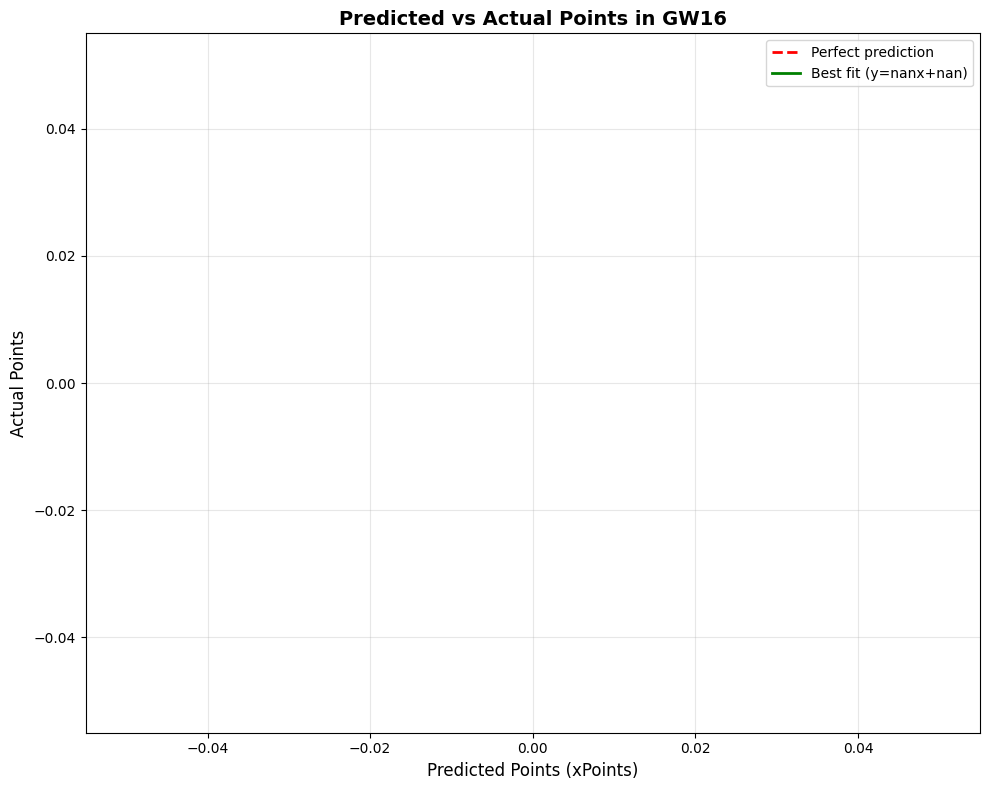

In [70]:
# Create the plot
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_complete, x='xpoints', y='total_points', alpha=0.6)

# Add a diagonal reference line (perfect predictions)
max_val = max(df_complete['xpoints'].max(), df_complete['total_points'].max())
plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction', linewidth=2)

# Add regression line showing actual correlation
from scipy.stats import linregress
slope, intercept, r_value, p_value, std_err = linregress(df_complete['xpoints'], df_complete['total_points'])
x_line = np.array([df_complete['xpoints'].min(), df_complete['xpoints'].max()])
y_line = slope * x_line + intercept
plt.plot(x_line, y_line, 'g-', label=f'Best fit (y={slope:.2f}x+{intercept:.2f})', linewidth=2)

print(f"Correlation: {df_complete['xpoints'].corr(df_complete['total_points']):.3f}")
print(f"Mean Absolute Error: {(df_complete['xpoints'] - df_complete['total_points']).abs().mean():.3f}")
print(f"Root Mean Squared Error: {((df_complete['xpoints'] - df_complete['total_points'])**2).mean()**0.5:.3f}")

plt.xlabel('Predicted Points (xPoints)', fontsize=12)
plt.ylabel('Actual Points', fontsize=12)
plt.title(f'Predicted vs Actual Points in GW{stats_current_gameweek}', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [71]:
finish=time.perf_counter()
print(f'Finished in {round(((finish-start)/60),2)} minute(s)')
#10/11/25: Finished in 8.91 minute(s)

Finished in 96.82 minute(s)
